# 03 - Back-EMF constant two ways

## Purpose

This notebook is the third in the series. It measures the back-EMF constant
$K_e$ of the motor, the voltage the winding generates per unit of speed, by
two routes that rest on different physics and different samples of the same
hardware, and it examines a third candidate channel that the data rejects.

This notebook has three jobs:

1. Measure $K_e$ by two independent routes and test their agreement
   (sections 5, 7 and 8). Route A needs the winding resistance $R$, which
   is anchored from the first two milliseconds of the full-duty steps
   (section 5.4).
2. Characterize the direct back-EMF channels, the terminal voltages read
   while the bridge leaves the winding floating, in the fast-decay drive
   grid (section 6) and in the coast segments (section 7).
3. Record the spread of every estimate across recordings (sections 5 to 7).

The dataset is three test series on one servo powered from a laptop USB
port, all captured on the current measurement chain (chain 3 of notebook
00). An earlier run of this notebook used a 2-cell battery on the previous
chain. Those recordings are retired and nothing below is fitted to them.
Where a number from that run is worth comparing, it is quoted and labeled.
Speed is the derivative of the pot wiper voltage, in wiper volts per
second, as in notebook 00. The gear ratio between motor and wiper is not
known here, so $K_e$ is expressed in volts per wiper volt per second and
no claim is made about the motor shaft constant.

## 1. Test setup

The device under test and the signal chain are those of notebook 00,
section 1: an SG90-class hobby servo with replacement electronics, a
brushed DC motor behind an H-bridge at 20 kHz PWM, a pot wiper on the
output shaft read directly by the 12-bit ADC, a 60 mOhm shunt in the motor
return path with an amplifier of gain 15.0, and both motor terminals read
through 6.8 kOhm / 3.3 kOhm dividers with a 150 pF reservoir capacitor at
each tap. The bottom leg of each terminal divider returns to a bias node
$V_B$ of about 0.63 V, so a terminal below ground still reads inside the
ADC range. The ADC runs at 48 MHz and scans the shunt, both terminals and
the pot each 50 us control period, and one frame of raw samples is streamed
per period.

Two facts about the bridge matter here.

- During the ON portion of a PWM period the bridge connects one terminal to
  the supply and the other to ground through the shunt.
- During the OFF portion the bridge has two modes. **Slow decay** closes
  both low-side switches and shorts the winding, so both terminals sit near
  ground and the winding current keeps circulating. **Fast decay** opens all
  four switches. The winding current then returns to the supply through the
  body diodes, during which the terminal that carries the current out of the
  winding sits one diode drop above the supply, the other sits one diode
  drop below ground, and the shunt reads negative. Once the current reaches
  zero the winding floats and the terminals carry the open-circuit back-EMF.

A **coast** segment is fast decay held at zero duty, so the winding floats
for the whole segment. A **brake** segment is slow decay at zero duty, so
the winding stays shorted.

Each sample row carries a shunt reading and both terminal readings taken at
one fixed point of the PWM period, the **crest scan**, plus a second shunt
reading from the opposite point of the period, the **trough scan**. Under
slow decay the crest scan falls inside the ON portion once the drive width
reaches 160 of the 1200 timer ticks (13.3% duty), and the firmware marks
those samples valid. Under fast decay the crest scan falls in the OFF
portion (notebook 01, section 5.3). Under slow decay the trough scan falls
in the OFF portion, where the circulating current bypasses the shunt, so
the trough shunt sample reads near zero at any partial duty and only the
crest sample carries the winding current.

**The supply sags.** A laptop USB port delivers about 4.6 V to the motor
at light load and about 4.4 V at full duty, and within a full-duty step
it dips by more than a volt for the first milliseconds while the inrush
current flows (notebook 00, section 6.2). Nothing below uses a nominal
rail. Every applied voltage is built from the terminal readings of the
same samples it is paired with.

**The board is a hacked rig.** The board under these series is a
development board that has been reworked by hand several times (the shunt,
the dividers, the bias return, the reservoir capacitors, a repaired
amplifier pad). Two defects of this rig show up in this notebook, and
neither one is coded around in shared code. The bus telemetry stream
couples into the current amplifier's output, so a shunt sample taken while
a frame is going out on the wire can read a few counts off. On the scan
geometry of this firmware build it does not show at rest (notebook 00,
section 5.2), and at the currents of this notebook it is worth a few mA at
most, which can bias a fit at the lowest drive steps by that much and is
negligible for $R$ and for $K_e$. The second defect is in the ADC of this
firmware build, which skips a band of codes below several of its binary
boundaries and reports the boundary code instead (section 4.3). That one
lands on readings this notebook needs, so section 4.3 measures it and
applies a workaround in this notebook only, labeled as such.

### 1.1 Model and routes

The winding obeys

$$v = R\,i + L\,\frac{di}{dt} + K_e\,\omega$$

with $v$ the terminal voltage, $i$ the winding current, $R$ the winding
resistance (brushes included), $L$ the winding inductance, $\omega$ the
speed and $K_e$ the back-EMF constant. Averaged over one PWM period the
inductive term is negligible on the millisecond scale of a drive step.
Under slow decay the OFF portion applies zero volts, so the mean terminal
voltage is the duty times the ON-portion terminal difference:

$$\bar v = D\,(v_{\mathrm{drv}} - v_{\mathrm{idle}}) = R\,\bar i + K_e\,\bar\omega$$

The equation is linear, so it holds for the means over any window of a
step, steady or not, as long as all three means come from the same window.
With the winding open, $i = 0$ and the terminal difference equals
$K_e\,\omega$ directly.

- **Route A** uses slow-decay drive steps. The mean voltage, mean current
  and mean speed over the last 60% of every valid step are fitted to the
  averaged equation, with $R$ anchored from the first milliseconds of the
  full-duty steps, before the mechanism has gathered speed.
- **Route C** uses the coast segments. The floating terminal difference is
  regressed on the instantaneous speed as the mechanism spins down.
- The **fast-decay crest sample**, one terminal reading per PWM period
  taken in the OFF portion, is the candidate for a direct back-EMF channel
  inside a drive step. Section 6 tests it against speed and current.

Route C and the candidate share the terminal channel and the
floating-winding physics. Route A shares nothing with them beyond the pot
wiper and the terminal dividers.

## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
the chain table of notebook 00. The shunt, the divider legs, the amplifier
gain and VDD are written into every recording's `meta.json` by the capture
tool (the `sense` block), and the loader in section 3 checks each recording
against this table and stops with an error if they disagree. The bias
divider, the reservoir capacitor and the sampling floors are not in the
metadata, so this table is the only record of them. The retired chain is
kept in the table so the numbers quoted from the earlier run can be read
against it. No data from it is loaded.

| Quantity | Chain 3 (this notebook) | Chain 2 (retired) |
|---|---|---|
| ADC resolution | 12 bit (0..4095 counts) | same |
| ADC reference | VDD, nominal 3.300 V | same |
| ADC clock | 48 MHz | slower, not recorded here |
| Motor terminal divider | 6.8 kOhm top / 3.3 kOhm bottom, bottom leg returned to the terminal bias | 20 kOhm / 10 kOhm, same return |
| Terminal tap reservoir | 150 pF per tap | none |
| Terminal bias $V_B$, nominal | 200 Ohm / 47 Ohm from VDD, 0.628 V | 430 Ohm / 100 Ohm from VDD, 0.623 V |
| Terminal bias $V_B$, measured | per recording and per terminal, from the segment-0 baseline (section 4) | same |
| Current shunt | 60 mOhm | 33 mOhm |
| Current amplifier gain | 15.0 | 15.0 |
| Control period | 50 us (20 kHz) | same |
| PWM counter | 1200 timer ticks per half period, center aligned | same |
| Duty encoding | signed, 32767 = 100% | same |
| Current sampling floor | 160 timer ticks = 13.3% duty | 160 ticks = 13.3% |
| Voltage sampling floor | 120 timer ticks = 10.0% duty | 210 ticks = 17.5% |

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{r} + \frac{r - 1}{r} V_B, \qquad V_t = r\,\text{tap} - (r - 1)\, V_B, \qquad r = \frac{R_\text{top} + R_\text{bot}}{R_\text{bot}} .$$

The divider ratio $r$ is 3.06 on chain 3. With the bridge off and no
current, both taps should read $V_B$. On this chain they do not read the
same. Terminal A rests about 18 counts below terminal B in every
recording, and the cause is open (notebook 00, section 5.3). Every
absolute terminal voltage below (the rail, the idle terminal, the coast
terminals) uses the second form with the terminal's own rest reading as
its $V_B$, which absorbs the split as an offset, the treatment of
notebook 00.

The **difference** of the two terminals is where this notebook lives, in
the applied voltage of route A and in the back-EMF of route C, and the
split matters there. A floating winding at rest has no voltage across it,
so the difference must read zero at rest whatever the two taps read. The
difference is therefore taken relative to each tap's rest reading:

$$V_a - V_b = r\,\big[(\text{tap}_a - \text{tap}_{a,\mathrm{rest}}) - (\text{tap}_b - \text{tap}_{b,\mathrm{rest}})\big]$$

Section 4.2 checks that the split at the end of every coast, with the
winding floating and the mechanism at rest, is the same 18 counts as in
the baseline, which is what makes this the right zero. Section 7.3 shows
what the other two readings of the split would do to route C.

Three caveats:

- The ADC reference is the chip's VDD supply. The 3.300 V figure is the
  design value, and the actual VDD of this unit was not measured. Every
  voltage below scales linearly with the true VDD. $K_e$ is a ratio of a
  terminal voltage to a wiper voltage per second, and both scale with VDD,
  so $K_e$ itself does not depend on it. $R$ does.
- The divider, shunt, and gain are design values. Component tolerances
  were not measured, and absolute voltages and currents carry them.
- $V_B$ enters only the absolute terminal voltages. A 1-count error in it
  moves an absolute terminal reading by $r - 1$ counts, about 1.7 mV.

The derived conversion factors, per chain:

In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- constants shared by both chains ---
ADC_COUNTS = 4096           # 12-bit converter
TICK_HZ = 20_000            # control / sample rate
PWM_HALF_TICKS = 1200       # timer ticks per PWM half period
Q15 = 32767                 # duty full scale as encoded on the wire

# --- per-chain constants (the table above) ---
# shunt/divider/gain/vdd are cross-checked against meta.json `sense`;
# bias divider and floors exist only here.
CHAIN_TABLE = {
    3: dict(label="chain 3", shunt_mohm=60, div_top=6_800, div_bot=3_300,
            gain_milli=15_000, vdd_mv=3_300, bias_top=200, bias_bot=47,
            floor_i_ticks=160, floor_v_ticks=120),
    2: dict(label="chain 2, retired", shunt_mohm=33, div_top=20_000, div_bot=10_000,
            gain_milli=15_000, vdd_mv=3_300, bias_top=430, bias_bot=100,
            floor_i_ticks=160, floor_v_ticks=210),
}
# which chain each campaign folder was captured on
CAMPAIGN_CHAIN = {"usb": 3, "bridge-usb": 3}

class Chain:
    # Conversion factors for one measurement chain.
    def __init__(self, n):
        c = CHAIN_TABLE[n]
        self.n, self.label = n, c["label"]
        self.vdd_v = c["vdd_mv"] / 1e3
        self.v_adc_per_count = self.vdd_v / ADC_COUNTS                  # volts at the ADC pin
        self.div_ratio = (c["div_top"] + c["div_bot"]) / c["div_bot"]  # r in the tap formula
        self.v_term_per_count = self.v_adc_per_count * self.div_ratio  # terminal volts per tap count
        self.vb_nom_v = self.vdd_v * c["bias_bot"] / (c["bias_top"] + c["bias_bot"])
        self.shunt_ohm = c["shunt_mohm"] / 1e3
        self.amp_gain = c["gain_milli"] / 1e3
        self.a_per_count = self.v_adc_per_count / (self.amp_gain * self.shunt_ohm)
        self.floor_i_pct = c["floor_i_ticks"] * 100.0 / PWM_HALF_TICKS
        self.floor_v_pct = c["floor_v_ticks"] * 100.0 / PWM_HALF_TICKS
        self.sense = {"shunt_r_mohm": c["shunt_mohm"], "vmotor_div_top": c["div_top"],
                      "vmotor_div_bot": c["div_bot"], "gain_milli": c["gain_milli"],
                      "vdd_mv": c["vdd_mv"]}

    def check_meta(self, meta, where):
        # Fail loudly if a recording was captured on different parts than
        # this table says. The keys are the capture tool's `sense` block.
        got = {k: meta["sense"][k] for k in self.sense}
        if got != self.sense:
            raise ValueError(f"{where}: meta.json sense {got} != {self.label} table {self.sense}")

    def term_V(self, tap_counts, vb_counts):
        # Absolute terminal voltage from a tap reading: Vt = r tap - (r-1) VB,
        # with the terminal's own rest reading as VB.
        return (self.div_ratio * tap_counts - (self.div_ratio - 1) * vb_counts) * self.v_adc_per_count

    def diff_V(self, tap_a, tap_b, vb_a, vb_b):
        # Terminal difference Va - Vb, relative to each tap's rest reading,
        # so a floating winding at rest reads zero (section 2).
        return self.div_ratio * ((tap_a - vb_a) - (tap_b - vb_b)) * self.v_adc_per_count

CHAINS = {n: Chain(n) for n in CHAIN_TABLE}
ch = CHAINS[3]               # every recording in this notebook is on chain 3

rows = []
for c in CHAINS.values():
    rows += [
        {"chain": c.label, "quantity": "pot wiper", "value": c.v_adc_per_count * 1e3, "unit": "mV per count"},
        {"chain": c.label, "quantity": "terminal divider ratio r", "value": c.div_ratio, "unit": ""},
        {"chain": c.label, "quantity": "motor terminal difference", "value": c.v_term_per_count * 1e3, "unit": "mV per count"},
        {"chain": c.label, "quantity": "terminal bias, nominal", "value": c.vb_nom_v * 1e3, "unit": "mV"},
        {"chain": c.label, "quantity": "terminal bias, nominal", "value": c.vb_nom_v / c.v_adc_per_count, "unit": "counts"},
        {"chain": c.label, "quantity": "motor current", "value": c.a_per_count * 1e3, "unit": "mA per count"},
        {"chain": c.label, "quantity": "current sampling floor", "value": c.floor_i_pct, "unit": "% duty"},
        {"chain": c.label, "quantity": "voltage sampling floor", "value": c.floor_v_pct, "unit": "% duty"},
    ]
pd.DataFrame(rows).set_index(["quantity", "unit", "chain"])["value"].unstack("chain").round(4)

chain                                   chain 2, retired   chain 3
quantity                  unit                                    
current sampling floor    % duty                 13.3333   13.3333
motor current             mA per count            1.6276    0.8952
motor terminal difference mV per count            2.4170    2.4658
pot wiper                 mV per count            0.8057    0.8057
terminal bias, nominal    counts                772.8302  779.4008
                          mV                    622.6415  627.9352
terminal divider ratio r                          3.0000    3.0606
voltage sampling floor    % duty                 17.5000   10.0000

## 3. Capture method

Three test series, all from the same servo on the same laptop USB port,
streamed at the full 20 kHz sample rate with a CRC on every frame.
Corrupted frames are dropped and counted, so corruption turns into missing
samples. The recordings live under `notebooks/telemetry/sg90/`.

- **Slow-decay grid.** The 41-segment recording of notebook 00: a
  one-second baseline with the motor undriven, then 80 ms constant-duty
  drive steps from 5% to 100% in 5% increments, forward then reverse, each
  preceded by a repositioning move toward the far end of travel at 15%
  duty and followed by 500 ms of rest. Fifteen recordings, the ten of the
  `usb` campaign and the five `slow` recordings of the `bridge-usb`
  campaign, which were captured alongside the other two series.
- **Fast-decay grid.** The same 41-segment grid with the bridge in fast
  decay during the drive steps. Five recordings, `bridge-usb/*/fast`.
- **Spin-down.** A one-second baseline, then for each direction the
  sequence drive 20% for 80 ms, coast 400 ms, drive 20%, brake 400 ms,
  drive 30%, coast, drive 30%, brake, drive 40%, coast, drive 40%, brake.
  Twenty-five segments per recording, five recordings,
  `bridge-usb/*/spindown`. The zero-duty segments alternate coast and
  brake and are identified by their position in the recorded schedule.

Between recordings the servo was rebooted and rested for one minute.

**Data acceptance.** Any recording with a dropped frame was discarded and
re-run. Section 4 re-verifies this from the tick column.

Each row of a recording is one 50 us sample and carries the segment
number, commanded duty, direction, tick counter, the validity flag, and
the raw channels (position, crest-scan shunt, trough-scan shunt, both
crest-scan terminals). The loader attaches to every recording its baseline
constants, the current offset (mean of `current_raw` over segment 0) and
the rest reading of each terminal tap (median of `vmotor_a` and of
`vmotor_b` over segment 0), and checks the recording's `sense` block
against the chain table.

In [2]:
TELEMETRY = Path("telemetry/sg90")

def load(csv, meta_path, chain):
    # One recording = per-tick samples + settings. Derived: duty_pct (signed
    # percent) and the per-recording baseline constants bias (current
    # offset, counts), vb (terminal A rest tap), vb_b (terminal B rest tap).
    df = pd.read_csv(csv)
    meta = json.loads(Path(meta_path).read_text())
    chain.check_meta(meta, csv)
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    return df, meta

def capture_dirs(campaign):
    base = TELEMETRY / campaign
    return sorted(base.glob("capture-*"), key=lambda p: int(p.name.split("-")[1]))

slow, fast, spin = {}, {}, {}
for d in capture_dirs("usb"):
    slow[f"usb/{d.name}"] = load(d / "sweep.csv.gz", d / "meta.json", CHAINS[CAMPAIGN_CHAIN["usb"]])
for d in capture_dirs("bridge-usb"):
    c = CHAINS[CAMPAIGN_CHAIN["bridge-usb"]]
    slow[f"bridge-usb/{d.name}"] = load(d / "slow.csv.gz", d / "slow.meta.json", c)
    fast[f"bridge-usb/{d.name}"] = load(d / "fast.csv.gz", d / "fast.meta.json", c)
    spin[f"bridge-usb/{d.name}"] = load(d / "spindown.csv.gz", d / "spindown.meta.json", c)

pd.DataFrame({"recordings": [len(slow), len(fast), len(spin)],
              "supply": [{m["supply"] for _, m in r.values()} for r in (slow, fast, spin)]},
             index=["slow-decay grid", "fast-decay grid", "spin-down"])

,recordings,supply
slow-decay grid,15,{usb}
fast-decay grid,5,{usb}
spin-down,5,{usb}


## 4. Data integrity, terminal bias, and the ADC

### 4.1 Missing samples, validity flag, bias

One frame carries 16 consecutive samples, so a dropped frame appears as a
16-tick jump inside a segment. The table recomputes the missing-sample
count of every recording from the tick column. It also reports the lowest
duty step at which the validity flag is set, which route A relies on, and
the rest reading of each terminal tap.

In [3]:
def integrity(recs, series):
    rows = []
    for name, (df, _) in recs.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        steps = df[df["seg"] > 0].groupby("seg").agg(
            d=("duty_pct", "first"), valid=("window_valid", "mean"))
        steps = steps[steps["d"] != 0]
        rows.append({
            "series": series,
            "recording": name,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
            "flag_set_from_pct": steps[steps["valid"] > 0.5]["d"].abs().min().round(),
            "VB_a_counts": df["vb"].iloc[0],
            "VB_b_counts": df["vb_b"].iloc[0],
            "VB_a_V": df["vb"].iloc[0] * ch.v_adc_per_count,
            "VB_b_V": df["vb_b"].iloc[0] * ch.v_adc_per_count,
            "current_offset_counts": df["bias"].iloc[0],
        })
    return pd.DataFrame(rows)

pd.concat([integrity(slow, "slow-decay grid"),
           integrity(fast, "fast-decay grid"),
           integrity(spin, "spin-down")], ignore_index=True).round(4)

,series,recording,samples,segments,missing_samples,flag_set_from_pct,VB_a_counts,VB_b_counts,VB_a_V,VB_b_V,current_offset_counts
0,slow-decay grid,usb/capture-1,84000,41,0,15.0,766.0,784.0,0.6171,0.6316,111.9842
1,slow-decay grid,usb/capture-2,84000,41,0,15.0,766.0,784.0,0.6171,0.6316,112.9630
2,slow-decay grid,usb/capture-3,84000,41,0,15.0,766.0,784.0,0.6171,0.6316,110.9205
3,slow-decay grid,usb/capture-4,84000,41,0,15.0,766.0,784.0,0.6171,0.6316,111.3192
4,slow-decay grid,usb/capture-5,84000,41,0,15.0,766.0,784.0,0.6171,0.6316,112.4661
5,slow-decay grid,usb/capture-6,84000,41,0,15.0,766.0,784.0,0.6171,0.6316,110.0214
6,slow-decay grid,usb/capture-7,84000,41,0,15.0,766.0,784.0,0.6171,0.6316,111.6494
7,slow-decay grid,usb/capture-8,84000,41,0,15.0,766.0,784.0,0.6171,0.6316,112.3280
8,slow-decay grid,usb/capture-9,84000,41,0,15.0,766.0,784.0,0.6171,0.6316,110.8196
9,slow-decay grid,usb/capture-10,84000,41,0,15.0,766.0,784.0,0.6171,0.6316,110.9970


Every recording has zero missing samples. In every grid recording the
flag is set from the 15% step up and clear at 10%, consistent with the
160-tick threshold. The spin-down drive steps are all at or above 20%.

The rest taps read 766 counts on terminal A (0.617 V) and 784 on terminal
B (0.632 V) in all 25 recordings, the 18-count split of notebook 00,
against the nominal 0.628 V. The first tens of milliseconds of every
baseline are the tail of a free coast from the positioning move, and the
full-second median absorbs it. The current offset sits at 110 to 113
counts, the USB session value of notebook 00.

### 4.2 The split with the winding floating

Section 2 takes the terminal difference relative to the rest reading of
each tap. That is only right if the split is the same when the winding
floats as it is in the baseline. The last 100 ms of every coast segment is
such a state, the bridge open for 300 ms already and the mechanism at rest,
which the pot slope over the same window confirms. The table compares the
tap split there with the baseline split, per recording.

In [4]:
def schedule_kinds(meta):
    kinds = []
    for _ in meta["dirs"]:
        level = None
        for entry in meta["schedule"]:
            if ":" in entry:
                kinds.append((entry.split(":")[0], level))
            else:
                level = float(entry)
                kinds.append(("drive", level))
    return kinds

def coast_segments(df, meta):
    kinds = schedule_kinds(meta)
    for seg_id, seg in df.groupby("seg"):
        if seg_id > 0 and kinds[seg_id - 1][0] == "coast":
            yield seg_id, kinds[seg_id - 1][1], seg

REST_TAIL = 2000                        # last 100 ms of a 400 ms coast

rows = []
for name, (df, meta) in spin.items():
    splits, slopes = [], []
    for _, _, seg in coast_segments(df, meta):
        tail = seg.iloc[-REST_TAIL:]
        splits.append((tail["vmotor_a"] - tail["vmotor_b"]).median())
        t = np.arange(REST_TAIL) / TICK_HZ
        slopes.append(abs(np.polyfit(t, tail["pos"] * ch.v_adc_per_count, 1)[0]))
    rows.append({"recording": name,
                 "baseline_split_counts": df["vb"].iloc[0] - df["vb_b"].iloc[0],
                 "coast_end_split_min": min(splits), "coast_end_split_max": max(splits),
                 "coast_end_pot_speed_max_Vps": max(slopes)})
pd.DataFrame(rows).set_index("recording").round(3)

,baseline_split_counts,coast_end_split_min,coast_end_split_max,coast_end_pot_speed_max_Vps
recording,,,,
bridge-usb/capture-1,-18.0,-18.0,-17.0,0.001
bridge-usb/capture-2,-18.0,-18.0,-17.0,0.005
bridge-usb/capture-3,-18.0,-18.0,-18.0,0.002
bridge-usb/capture-4,-18.0,-18.0,-17.0,0.002
bridge-usb/capture-5,-18.0,-18.0,-17.0,0.003


The split at the end of every coast is 17 to 18 counts, terminal A below
B, the same as the baseline, with the pot moving at no more than a few
millivolts per second. So whatever the split is, it is there whenever the
winding floats at rest, and subtracting each tap's rest reading is what
zeroes the difference of a floating winding.

### 4.3 The ADC skips codes on this build

While tabulating the first drive steps I found the pot reading sitting at
exactly 1024 for a dozen milliseconds at a time while the mechanism was
moving, with readings in the 960s just before and readings of 1025 and up
just after. The current channel does the same during the inrush of a
full-duty step, a run of 1024 between a falling 1031 and a 964. A
12-bit converter that never produces the codes between 969 and 1023 and
reports 1024 for all of them is skipping codes just below a binary
boundary, a settling error at that bit's decision. The table below scans
the pooled samples of all three series for every channel and every
boundary code, and reports two things. The first is how many codes just
below the boundary never occur. The second is how many readings sit
exactly at the boundary code compared with the average of the ten codes
just above it, which is the pile-up of the skipped band. The pot rests at
a few favourite positions and does not cover every code, so a run of
absent codes on the pot without a pile-up is coverage, not a defect.

In [5]:
BOUNDARY_CODES = [128, 256, 512, 1024, 1536, 2048, 2560]
RAW_CHANNELS = ["pos", "current_raw", "current_trough", "vmotor_a", "vmotor_b"]

pooled = pd.concat([df for recs in (slow, fast, spin) for df, _ in recs.values()], ignore_index=True)

def band_below(values, code, span=80):
    # width of the run of codes ending at code-1 that never occur
    seen = np.bincount(values, minlength=code + 1)[code - span:code] > 0
    run = 0
    for s in seen[::-1]:
        if s:
            break
        run += 1
    return run

def pile_ratio(values, code):
    # readings at the boundary code over the mean count of the ten codes above
    h = np.bincount(values, minlength=code + 12)
    above = h[code + 1:code + 11].mean()
    return h[code] / above if above > 0 else np.nan

rows = []
for col in RAW_CHANNELS:
    v = pooled[col].to_numpy().astype(int)
    for b in BOUNDARY_CODES:
        if v.min() > b - 80 or v.max() < b + 12:
            continue                       # channel never reaches this boundary
        rows.append({"channel": col, "boundary": b,
                     "codes_never_seen_below": band_below(v, b),
                     "readings_at_boundary_vs_above": pile_ratio(v, b)})
bands = pd.DataFrame(rows).set_index(["channel", "boundary"]).unstack("boundary")
bands.round(1)

codes_never_seen_below                                    \
boundary                         128  256   512   1024  1536 2048  2560   
channel                                                                   
current_raw                       2.0  9.0  27.0  55.0   NaN  NaN   NaN   
current_trough                    NaN  9.0  27.0  55.0   NaN  NaN   NaN   
pos                               NaN  NaN   NaN  53.0  17.0  4.0   0.0   
vmotor_a                          NaN  NaN  27.0  55.0   0.0  0.0  36.0   
vmotor_b                          NaN  NaN  27.0  54.0   0.0  0.0  36.0   

               readings_at_boundary_vs_above                                \
boundary                                128   256   512    1024  1536 2048   
channel                                                                      
current_raw                             15.0  11.3  30.3  145.1   NaN  NaN   
current_trough                           NaN  10.3  35.5  375.8   NaN  NaN   
pos                                      NaN   NaN   NaN   69.6  14.0  0.0   
vmotor_a                                 NaN   NaN   0.2   54.7   NaN  0.0   
vmotor_b                                 NaN   NaN   0.4   77.6   NaN  0.0   

                      
boundary        2560  
channel               
current_raw      NaN  
current_trough   NaN  
pos              0.0  
vmotor_a        23.6  
vmotor_b        26.2

The pattern is a band of skipped codes below 128, 256, 512 and 1024 on
every channel that reaches them, 2, 9, 27 and 53 to 55 codes wide,
doubling with each boundary, with a pile-up of ten to hundreds of times
the neighbouring density at the boundary code. The one place the pile-up
does not show is 512 on the terminals, because the ten codes above 512
are where a terminal rests at 0 V and are crowded already, but the 27
skipped codes below it are there just the same. The terminals show the
same at 2560 (36 codes) and the pot at 1536 (17 codes). At 2048 there is
no pile-up on any channel, so that boundary resolves. The recordings of the
retired chain, taken with an earlier firmware build and a slower ADC
clock, have none of this (I checked the same scan on them, and it is not
shown here because that data is retired). This is a limitation of this
firmware build on this rig, not of the servo, and the next hardware
revision will be measured without it.

It lands where this notebook reads. The pot passes through 969 to 1023
during many drive steps, which is a 12 ms plateau in a speed fit. The
negative terminal of a floating winding sits between the diode level and
0 V while the back-EMF decays, and 0 V is tap 516 on terminal A and 528
on terminal B, right above the band below 512. The current during the
inrush of a full-duty step passes through the band below 1024.

**Rig workaround, this notebook only.** A reading equal to a boundary code
is ambiguous. The true code is anywhere in the skipped band or at the
boundary itself. Every such reading in the five raw channels is dropped
and replaced by linear interpolation in time between its nearest
non-boundary neighbours within the segment. All five signals are smooth
over the 50 us sample period, and the plateaus sit in slowly varying
stretches (a pot at speed, a decaying current, a terminal drifting up
through the diode level), so the interpolation error is a small fraction
of the band width. Where a plateau reaches the end of a segment the last
good value is held, which leaves an error of up to the band width on that
stretch. The table reports the share of samples touched per channel and
series. Nothing in the shared helpers of this series does this, so the
notebooks written for the next board do not inherit it.

In [6]:
PINNED_CODES = [b for b in BOUNDARY_CODES if b != 2048]   # 2048 resolves, the rest pile up

def unpin(df):
    # RIG WORKAROUND (this build only): boundary-code readings are unknown
    # within the skipped band. Drop them and interpolate in time, per segment.
    for col in RAW_CHANNELS:
        s = df[col].astype(float)
        s[s.isin(PINNED_CODES)] = np.nan
        df[col] = s.groupby(df["seg"]).transform(lambda x: x.interpolate(limit_direction="both"))
    return df

rows = []
for label, recs in [("slow-decay grid", slow), ("fast-decay grid", fast), ("spin-down", spin)]:
    for name, (df, meta) in recs.items():
        touched = {col: df[col].isin(PINNED_CODES).mean() * 100 for col in RAW_CHANNELS}
        rows.append({"series": label, **touched})
        recs[name] = (unpin(df), meta)
touched = pd.DataFrame(rows).groupby("series").mean()
touched.columns = [f"{c}_pct_of_samples" for c in touched.columns]
touched.round(2)

,pos_pct_of_samples,current_raw_pct_of_samples,current_trough_pct_of_samples,vmotor_a_pct_of_samples,vmotor_b_pct_of_samples
series,,,,,
fast-decay grid,5.12,0.96,4.35,2.20,1.28
slow-decay grid,6.77,6.86,6.66,0.00,0.00
spin-down,1.95,0.48,0.48,0.85,0.16


The pot is touched in 5 to 7% of the grid samples, because the servo
parks at 940 to 965 counts before every forward step and drives through
the band below 1024, and in 6% of the samples inside the route A windows.
The current channel is touched in 7% of the slow-grid samples. A third of
those are the 5% steps, which nothing below uses, sitting in the 2-code
band below 128. Most of the rest are readings in the 9-code band below
256, which the current ripple visits at every duty, 6% of the samples in
the route A windows, each off by at most 8 mA before interpolation. The
bands below 512 and 1024 are hit only during the inrush of the high-duty
steps. The terminals are touched in under 1% of the spin-down samples,
concentrated in the coast decays, where section 7.3 counts them.
Everything below uses the interpolated channels.

## 5. Route A: slow-decay drive steps

### 5.1 Per-step quantities

For every drive step with the validity flag set, over the last 60% of the
step, 48 ms:

- **Applied voltage** $\bar v = D\,\overline{(v_{\mathrm{drv}} - v_{\mathrm{idle}})}$.
  The terminal difference is taken per crest-scan sample with the
  rest-relative form of section 2, then averaged over the valid samples
  of the window. On a supply that sags within a step this is the measured
  ON-portion voltage the winding actually saw over the window, and no
  nominal rail enters. The driven terminal's 90th percentile (the supply
  estimate of notebook 00) and the idle terminal's median are tabulated
  alongside for reference.
- **Current** $\bar i$ is the mean valid crest-scan shunt reading over the
  window minus the baseline offset of the same recording, signed by
  direction. The crest scan sits at the centre of the ON portion, and the
  current ripple within a period is close to triangular, so the centre
  sample is taken as the period mean.
- **Speed** $\bar\omega$ is the slope of a least-squares line through the
  window's wiper trace, the method of notebook 00, section 6.3, which
  agrees with the window's travel over its duration to 0.3%.

The earlier run of this notebook took the applied voltage from the
whole-step 90th percentile of the driven terminal and the current from the
whole-step mean, while the speed came from the last 60%. That pairs a
current that still carries the inrush with a speed that does not, and on
this supply the inrush is a large part of a step (section 5.4). Section
5.5 shows what that older definition gives on this data, so the earlier
result can be compared, and how the result moves with the window.

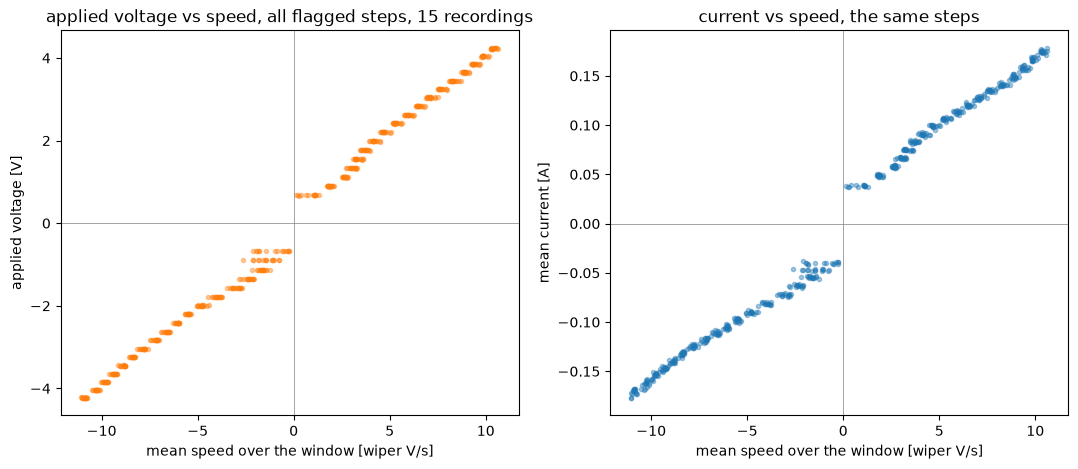

,speed_Vps,valid_frac,rail_V,idle_V,on_V,current_A,applied_V
duty_pct,,,,,,,
14.999847,1.097,0.999,4.617,0.106,4.517,0.038,0.678
19.998779,1.796,0.999,4.607,0.106,4.500,0.050,0.900
24.997711,2.668,0.999,4.595,0.106,4.487,0.059,1.122
29.999695,2.935,0.999,4.587,0.119,4.472,0.067,1.341
34.998627,3.615,0.999,4.580,0.119,4.455,0.075,1.559
39.997559,3.758,0.999,4.570,0.129,4.437,0.085,1.775
44.999542,4.189,0.999,4.555,0.129,4.421,0.092,1.989
49.998474,4.614,0.999,4.545,0.129,4.406,0.099,2.203
54.997406,5.190,0.999,4.538,0.129,4.391,0.107,2.415


In [7]:
TAIL = 0.6                  # fraction of each step used, the last 60% as in notebook 00

def step_window(seg, frac=TAIL):
    return seg.iloc[int(len(seg) * (1 - frac)):]

def step_speed(seg):
    t = (seg["tick"] - seg["tick"].iloc[0]) / TICK_HZ
    return np.polyfit(t, seg["pos"] * ch.v_adc_per_count, 1)[0]

def drive_steps(df, frac=TAIL):
    vb_a, vb_b, bias = df["vb"].iloc[0], df["vb_b"].iloc[0], df["bias"].iloc[0]
    out = []
    for seg_id, seg in df.groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        if seg_id == 0 or d == 0:
            continue
        sgn = int(np.sign(d))
        drv, idle, vb_d, vb_i = ("vmotor_a", "vmotor_b", vb_a, vb_b) if d > 0 else ("vmotor_b", "vmotor_a", vb_b, vb_a)
        w = step_window(seg, frac)
        v = w[w["window_valid"] == 1]
        row = {"duty_pct": d, "speed_Vps": step_speed(w), "valid_frac": seg["window_valid"].mean()}
        if len(v) >= 100:
            row.update({
                "rail_V": ch.term_V(v[drv].quantile(0.9), vb_d),
                "idle_V": ch.term_V(v[idle].median(), vb_i),
                "on_V": sgn * ch.diff_V(v["vmotor_a"], v["vmotor_b"], vb_a, vb_b).mean(),
                "current_A": sgn * (v["current_raw"].mean() - bias) * ch.a_per_count,
            })
        out.append(row)
    s = pd.DataFrame(out)
    s["applied_V"] = s["duty_pct"] / 100.0 * s["on_V"]
    return s

steps_a = {name: drive_steps(df).dropna(subset=["current_A"])
           for name, (df, _) in slow.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, s in steps_a.items():
    axes[0].plot(s["speed_Vps"], s["applied_V"], "o", ms=3, alpha=0.4, color="tab:orange")
    axes[1].plot(s["speed_Vps"], s["current_A"], "o", ms=3, alpha=0.4, color="tab:blue")
axes[0].set_xlabel("mean speed over the window [wiper V/s]")
axes[0].set_ylabel("applied voltage [V]")
axes[0].set_title("applied voltage vs speed, all flagged steps, 15 recordings")
axes[1].set_xlabel("mean speed over the window [wiper V/s]")
axes[1].set_ylabel("mean current [A]")
axes[1].set_title("current vs speed, the same steps")
for ax in axes:
    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5)
plt.show()

steps_a["bridge-usb/capture-1"].set_index("duty_pct").round(3)

The driven terminal's 90th percentile reads 4.40 to 4.62 V across the
flagged steps of all 15 recordings, falling with duty as the USB rail sags
under load, and the idle terminal 0.02 to 0.15 V, rising with current. The
15% step barely moves on this supply (0.68 V applied against the 0.37 to
0.46 V motion threshold of notebook 00), and the 20% step is the first
with a clear speed. The right panel is the problem of route A in one
picture. Current and speed rise together across the grid, so the two
regressors of the joint fit are nearly proportional and the fit can trade
$R$ against $K_e$ with little change in residual. Section 5.3 quantifies
this and section 5.4 breaks the tie with an independent $R$.

### 5.2 Joint fit

Per recording, $\bar v = R\,\bar i + K_e\,\bar\omega$ is fitted by least
squares over all flagged steps of both directions with no intercept. The
signs are consistent by construction, since reverse steps carry negative
voltage, negative current and negative speed.

In [8]:
def fit_route_a(s):
    A = np.column_stack([s["current_A"], s["speed_Vps"]])
    x, _, _, sv = np.linalg.lstsq(A, s["applied_V"], rcond=None)
    resid = s["applied_V"] - A @ x
    return {"R_ohm": x[0], "Ke_V_per_Vps": x[1],
            "rms_resid_V": np.sqrt(np.mean(resid ** 2)),
            "corr_i_w": np.corrcoef(s["current_A"], s["speed_Vps"])[0, 1],
            "condition": sv[0] / sv[1], "steps": len(s)}

fits_a = pd.DataFrame([{"recording": n, **fit_route_a(s)} for n, s in steps_a.items()])
fits_a.set_index("recording").round(4)

,R_ohm,Ke_V_per_Vps,rms_resid_V,corr_i_w,condition,steps
recording,,,,,,
usb/capture-1,13.7440,0.1619,0.0660,0.9943,529.3882,36
usb/capture-2,14.3539,0.1582,0.0492,0.9936,520.6028,36
usb/capture-3,13.7595,0.1696,0.0609,0.9916,448.9114,36
usb/capture-4,13.5566,0.1731,0.0614,0.9941,504.9019,36
usb/capture-5,14.3272,0.1663,0.0758,0.9951,549.5971,36
usb/capture-6,13.6240,0.1738,0.0564,0.9926,458.7854,36
usb/capture-7,13.2369,0.1823,0.0686,0.9943,523.8282,36
usb/capture-8,13.7054,0.1735,0.0723,0.9929,458.5007,36
usb/capture-9,14.1240,0.1688,0.0593,0.9909,418.1066,36


In [9]:
summary_a = fits_a[["R_ohm", "Ke_V_per_Vps"]].agg(["mean", "std", "min", "max"]).T
summary_a["spread_pct"] = summary_a["std"] / summary_a["mean"].abs() * 100
summary_a.round(4)

,mean,std,min,max,spread_pct
R_ohm,13.9364,0.4176,13.2369,14.7284,2.9966
Ke_V_per_Vps,0.1701,0.0071,0.1582,0.1823,4.1754


### 5.3 Collinearity

The correlation between current and speed across the steps of a recording
is above 0.98 and the condition number of the design matrix is in the
hundreds. The joint fit therefore pins one combination of $R$ and $K_e$
and leaves the split between them weak. To make this concrete, for one
recording $K_e$ is stepped through a grid, $R$ is refitted at each value,
and the residual is tabulated.

In [10]:
def ke_at_fixed_r(s, r):
    return np.sum(s["speed_Vps"] * (s["applied_V"] - r * s["current_A"])) / np.sum(s["speed_Vps"] ** 2)

s = steps_a["bridge-usb/capture-1"]
rows = []
for ke in np.arange(0.15, 0.50, 0.05):
    r = np.sum(s["current_A"] * (s["applied_V"] - ke * s["speed_Vps"])) / np.sum(s["current_A"] ** 2)
    resid = s["applied_V"] - r * s["current_A"] - ke * s["speed_Vps"]
    rows.append({"Ke_fixed": round(ke, 2), "R_refit_ohm": r,
                 "rms_resid_V": np.sqrt(np.mean(resid ** 2))})
pd.DataFrame(rows).set_index("Ke_fixed").round(4)

,R_refit_ohm,rms_resid_V
Ke_fixed,,
0.15,15.2087,0.0713
0.20,12.3525,0.0688
0.25,9.4963,0.0896
0.30,6.6401,0.1222
0.35,3.7839,0.1596
0.40,0.9277,0.1992
0.45,-1.9285,0.2398


Findings:

- The free joint fit lands at $K_e$ = 0.17 V per wiper V/s and $R$ = 13.9
  Ohm, with a 4% spread across the 15 recordings. That $R$ is three times
  the winding resistance the full-duty steps show directly (section 5.4),
  so the free fit is not a measurement of either constant. It is the best
  two-term line through steps whose current and speed rise together.
- The residual valley is not shallow on this supply, it is one-sided.
  Moving $K_e$ from 0.20 to 0.35 raises the rms residual from 0.069 V to
  0.160 V while $R$ swings from 12.4 Ohm to 3.8 Ohm. Something in the
  steps is not in the two-term model. Section 5.5 shows that a constant
  voltage term of about a quarter volt absorbs most of it, and section 9
  lists the candidates.
- What the grid pins on its own is the combination $R + 57\,K_e \approx
  23.5$ Ohm, the ratio 57 being the speed per ampere the fit sees across
  the flagged steps (it was 35 on the 7.4 V battery, where the same speed
  costs less current).

### 5.4 An independent anchor for R

The full-duty steps offer $R$ on its own. When the bridge switches on, the
current rises to its stall value within a few hundred microseconds, the
inductive term dies with it, and the mechanism has not yet gathered speed.
Over the window from 0.6 ms to 2 ms after the bridge switches on, the ratio
of the mean terminal difference to the mean crest-scan current is $R$ plus
whatever back-EMF the mechanism carries into the window, divided by the
current. The terminal difference is measured per sample, which matters
here, because the USB rail sags by more than a volt under the 0.8 A
inrush and the terminal difference in the window is 3.3 V, not the 4.4 V
of the settled step.

That residual back-EMF is the caveat. The positioning move that precedes
each step runs toward the far end of travel at the 15% seek duty and ends
at the step edge, so the mechanism enters the step moving backward. The
first sample of the segment, before the bridge switches on, carries no
current and reads the terminal difference of the free winding, a backward
EMF. On this supply the seek runs at 0.68 V, just above the motion
threshold, so the backward EMF at the edge is about a third of a volt
against 0.7 V on the battery. The pot's slope over the first 2 ms is
tabulated too, but at these entry speeds it is inside the pot's noise. The
figure averages the first 10 ms of all 30 full-duty steps, with the anchor
window shaded.

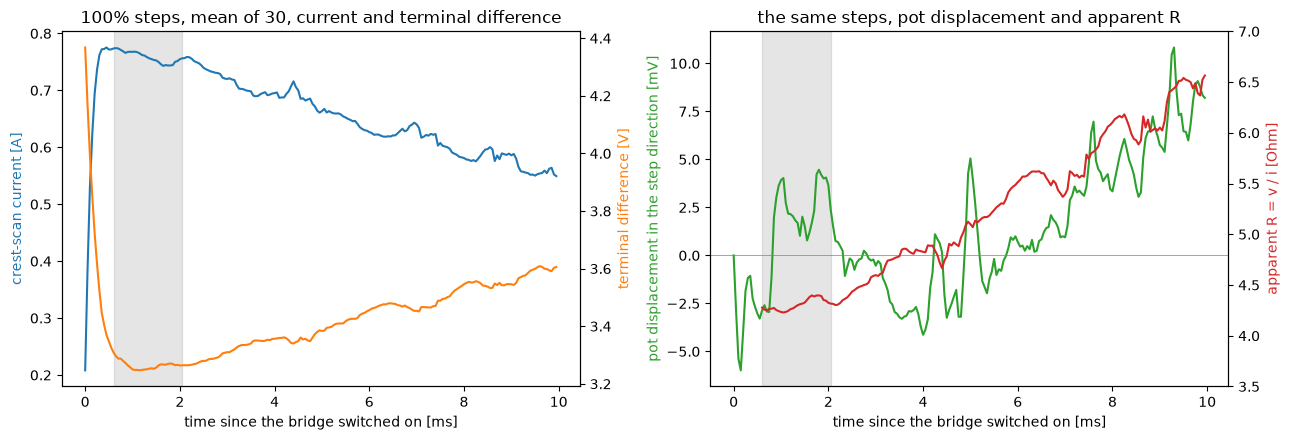

bridge_on_sample  e_edge_V  i_edge_A  \
recording            direction                                         
usb/capture-1         1                        2    -0.333     0.004   
                     -1                        2    -0.385     0.002   
usb/capture-2         1                        2    -0.390     0.004   
                     -1                        2    -0.402     0.003   
usb/capture-3         1                        3    -0.343     0.005   
                     -1                        2    -0.365     0.005   
usb/capture-4         1                        2    -0.311     0.004   
                     -1                        2    -0.330     0.002   
usb/capture-5         1                        3    -0.375     0.001   
                     -1                        2    -0.321     0.001   
usb/capture-6         1                        2    -0.333     0.005   
                     -1                        3    -0.330     0.006   
usb/capture-7         1                        2    -0.382    -0.001   
                     -1                        2    -0.399     0.004   
usb/capture-8         1                        2    -0.358     0.005   
                     -1                        2    -0.375     0.003   
usb/capture-9         1                        2    -0.286     0.005   
                     -1                        2    -0.343     0.005   
usb/capture-10        1                        2    -0.321     0.004   
                     -1                        2    -0.367     0.004   
bridge-usb/capture-1  1                        3    -0.296     0.002   
                     -1                        2    -0.321     0.005   
bridge-usb/capture-2  1                        2    -0.296     0.005   
                     -1                        2    -0.377     0.005   
bridge-usb/capture-3  1                        2    -0.259     0.002   
                     -1                        2    -0.392     0.004   
bridge-usb/capture-4  1                        2    -0.318     0.006   
                     -1                        2    -0.328     0.004   
bridge-usb/capture-5  1                        2    -0.271     0.004   
                     -1                        3    -0.385     0.004   

                                pot_speed_2ms_Vps  v_window_V  i_window_A  \
recording            direction                                              
usb/capture-1         1                    -6.541       3.234       0.797   
                     -1                    10.339       3.191       0.789   
usb/capture-2         1                     0.292       3.245       0.820   
                     -1                    23.370       3.153       0.827   
usb/capture-3         1                    -4.666       3.295       0.769   
                     -1                    10.780       3.228       0.754   
usb/capture-4         1                    -6.033       3.299       0.747   
                     -1                     9.278       3.240       0.754   
usb/capture-5         1                    -2.220       3.312       0.768   
                     -1                     9.149       3.216       0.755   
usb/capture-6         1                    -3.054       3.322       0.741   
                     -1                    11.869       3.224       0.753   
usb/capture-7         1                    -4.553       3.309       0.758   
                     -1                     9.716       3.225       0.748   
usb/capture-8         1                    -3.672       3.301       0.764   
                     -1                    12.433       3.195       0.776   
usb/capture-9         1                    -4.856       3.332       0.734   
                     -1                    10.064       3.243       0.737   
usb/capture-10        1                    -3.400       3.326       0.737   
                     -1                     9.143       3.234       0.741   
bridge-usb/capture-1  1          

In [11]:
ANCHOR_WINDOW = (12, 41)                 # samples after the bridge switches on, 0.6 ms to 2 ms
LATER_WINDOWS = {"R_0.6_1ms": (12, 21), "R_1_2ms": (21, 41), "R_2_3ms": (41, 61), "R_3_4ms": (61, 81)}
TRACE_SAMPLES = 200                      # 10 ms of the step start kept for the figure
BRIDGE_ON_A = 0.1                        # current that marks the first sample with the bridge on

def full_duty_steps(df):
    vb_a, vb_b, bias = df["vb"].iloc[0], df["vb_b"].iloc[0], df["bias"].iloc[0]
    for seg_id, seg in df.groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        if seg_id == 0 or abs(d) < 99.9:
            continue
        sgn = int(np.sign(d))
        v = sgn * ch.diff_V(seg["vmotor_a"].to_numpy(), seg["vmotor_b"].to_numpy(), vb_a, vb_b)
        i = (seg["current_raw"].to_numpy() - bias) * ch.a_per_count
        pos = sgn * seg["pos"].to_numpy() * ch.v_adc_per_count
        on = int(np.flatnonzero(i > BRIDGE_ON_A)[0])
        yield sgn, on, v, i, pos

def window_ratio(v, i, on, lo, hi):
    return v[on + lo:on + hi].mean() / i[on + lo:on + hi].mean()

rows, traces = [], []
lo, hi = ANCHOR_WINDOW
t2 = np.arange(41) / TICK_HZ
for name, (df, _) in slow.items():
    for sgn, on, v, i, pos in full_duty_steps(df):
        row = {"recording": name, "direction": sgn, "bridge_on_sample": on,
               "e_edge_V": v[0], "i_edge_A": i[0],
               "pot_speed_2ms_Vps": np.polyfit(t2, pos[on:on + 41], 1)[0],
               "v_window_V": v[on + lo:on + hi].mean(),
               "i_window_A": i[on + lo:on + hi].mean(),
               "R_window_ohm": window_ratio(v, i, on, lo, hi)}
        row.update({k: window_ratio(v, i, on, a, b) for k, (a, b) in LATER_WINDOWS.items()})
        rows.append(row)
        traces.append(np.column_stack([i[on:on + TRACE_SAMPLES], v[on:on + TRACE_SAMPLES],
                                       (pos[on:on + TRACE_SAMPLES] - pos[on]) * 1e3]))
anchor = pd.DataFrame(rows)
mean_trace = np.mean(traces, axis=0)
tm = np.arange(TRACE_SAMPLES) / TICK_HZ * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(tm, mean_trace[:, 0], color="tab:blue")
ax.set_ylabel("crest-scan current [A]", color="tab:blue")
ax2 = ax.twinx()
ax2.plot(tm, mean_trace[:, 1], color="tab:orange")
ax2.set_ylabel("terminal difference [V]", color="tab:orange")
ax.axvspan(lo / TICK_HZ * 1e3, hi / TICK_HZ * 1e3, color="grey", alpha=0.2)
ax.set_xlabel("time since the bridge switched on [ms]")
ax.set_title("100% steps, mean of 30, current and terminal difference")
ax = axes[1]
ax.plot(tm, mean_trace[:, 2], color="tab:green")
ax.set_ylabel("pot displacement in the step direction [mV]", color="tab:green")
ax.axhline(0, color="grey", lw=0.5)
ax2 = ax.twinx()
ax2.plot(tm[lo:], mean_trace[lo:, 1] / mean_trace[lo:, 0], color="tab:red")
ax2.set_ylabel("apparent R = v / i [Ohm]", color="tab:red")
ax2.set_ylim(3.5, 7.0)
ax.axvspan(lo / TICK_HZ * 1e3, hi / TICK_HZ * 1e3, color="grey", alpha=0.2)
ax.set_xlabel("time since the bridge switched on [ms]")
ax.set_title("the same steps, pot displacement and apparent R")
fig.tight_layout()
plt.show()

anchor.set_index(["recording", "direction"]).round(3)

In [12]:
cols = ["R_window_ohm", *LATER_WINDOWS, "e_edge_V", "i_edge_A", "pot_speed_2ms_Vps", "i_window_A", "v_window_V"]
summary_r = anchor[cols].agg(["mean", "std", "min", "max"]).T
summary_r["spread_pct"] = summary_r["std"] / summary_r["mean"].abs() * 100
summary_r.round(4)

,mean,std,min,max,spread_pct
R_window_ohm,4.3094,0.1856,3.8133,4.5494,4.3062
R_0.6_1ms,4.2658,0.2078,3.6148,4.4669,4.8712
R_1_2ms,4.3324,0.2098,3.8063,4.6083,4.8423
R_2_3ms,4.4584,0.3594,3.4984,4.8217,8.0611
R_3_4ms,4.7834,0.2788,3.9594,5.0941,5.8294
e_edge_V,-0.3430,0.0392,-0.4019,-0.2589,11.4285
i_edge_A,0.0038,0.0015,-0.0006,0.0062,39.3579
pot_speed_2ms_Vps,4.0310,9.1835,-6.5408,27.3701,227.8210
i_window_A,0.7586,0.0252,0.7334,0.8268,3.3208
v_window_V,3.2648,0.0531,3.1530,3.3408,1.6273


Findings:

- The window ratio repeats to 4.3% across the 30 steps, 4.31 Ohm with a
  spread of 0.19 Ohm. The stall current in the window is 0.76 A against
  the 1.6 A of the battery run, and the terminal difference in the window
  is 3.26 V, the sagged rail.
- Every step enters with a backward EMF at the edge, 0.26 to 0.40 V with
  at most 0.006 A of current. The pot's 2 ms slope is not usable here. It
  reads -7 to +27 V/s, and the sign flips with the step direction, which
  is not motion (the mechanism cannot reach that speed in 2 ms) but the
  pot reading shifting by a few counts while the 0.8 A inrush flows,
  visible in the raw trace as a step of 5 to 9 counts that comes and
  goes with the current. So the edge EMF is the only reading of the entry
  motion. There is no resting population to select, so no step is
  excluded and the residual motion is carried as a systematic.
- The apparent $R$ climbs through successive windows, 4.27 Ohm at 0.6 to
  1 ms, 4.33 at 1 to 2 ms, 4.46 at 2 to 3 ms and 4.78 at 3 to 4 ms, as
  the backward EMF dies and the forward EMF takes over. The pot
  displacement bottoms out near 4 ms, and from there the apparent $R$
  rises steeply in the figure, the forward EMF growing faster on this
  supply's lighter stall current than it did on the battery.

The residual backward EMF adds to the terminal difference that the bridge
must overcome, so the window ratio reads low. Two bounds bracket the true
$R$ without a model of the reversal. The lower bound takes the residual
EMF in the window as zero, the window ratio as read. The upper bound holds
the edge EMF unchanged through the window and adds it back to the terminal
difference. The anchor is the midpoint of the bounds with the half-range
as its uncertainty.

In [13]:
r_low = anchor["R_window_ohm"]
r_high = (anchor["v_window_V"] - anchor["e_edge_V"]) / anchor["i_window_A"]
R_ANCHOR = (r_low.mean() + r_high.mean()) / 2
R_ANCHOR_HALF = (r_high.mean() - r_low.mean()) / 2

pd.DataFrame([
    {"bound": "lower, residual EMF in the window taken as zero", "R_ohm": r_low.mean(), "std_over_30_steps": r_low.std()},
    {"bound": "upper, edge EMF held through the window", "R_ohm": r_high.mean(), "std_over_30_steps": r_high.std()},
    {"bound": "anchor, midpoint with half-range", "R_ohm": R_ANCHOR, "half_range": R_ANCHOR_HALF},
]).set_index("bound").round(4).fillna("")

,R_ohm,std_over_30_steps,half_range
bound,,,
"lower, residual EMF in the window taken as zero",4.3094,0.1856,
"upper, edge EMF held through the window",4.7611,0.1704,
"anchor, midpoint with half-range",4.5352,,0.2259


### 5.5 Route A with R anchored

With $R$ fixed at the anchor, $K_e$ alone is refitted per recording. The
same is done at the two bounds, so the table carries both the recording
spread and the shift that the anchor's uncertainty induces.

In [14]:
R_GRID = {"Ke_at_R_lower": R_ANCHOR - R_ANCHOR_HALF, "Ke_at_R_anchor": R_ANCHOR, "Ke_at_R_upper": R_ANCHOR + R_ANCHOR_HALF}
ke_anchor = pd.DataFrame({k: pd.Series({n: ke_at_fixed_r(s, r) for n, s in steps_a.items()})
                          for k, r in R_GRID.items()})
KE_A = ke_anchor["Ke_at_R_anchor"].mean()
KE_A_STD = ke_anchor["Ke_at_R_anchor"].std()
KE_A_SHIFT = (ke_anchor["Ke_at_R_lower"].mean() - ke_anchor["Ke_at_R_upper"].mean()) / 2
KE_A_SPREAD = np.hypot(KE_A_STD, KE_A_SHIFT)

summary = ke_anchor.agg(["mean", "std", "min", "max"])
summary.loc["R_ohm"] = list(R_GRID.values())
summary.loc["spread_pct"] = summary.loc["std"] / summary.loc["mean"] * 100
pd.concat([ke_anchor, summary]).round(4)

,Ke_at_R_lower,Ke_at_R_anchor,Ke_at_R_upper
usb/capture-1,0.3222,0.3183,0.3145
usb/capture-2,0.3262,0.3225,0.3187
usb/capture-3,0.3300,0.3261,0.3223
usb/capture-4,0.3320,0.3282,0.3243
usb/capture-5,0.3348,0.3310,0.3272
usb/capture-6,0.3339,0.3301,0.3262
usb/capture-7,0.3346,0.3308,0.3269
usb/capture-8,0.3353,0.3314,0.3275
usb/capture-9,0.3378,0.3339,0.3301
usb/capture-10,0.3387,0.3348,0.3309


In [15]:
pd.DataFrame([{
    "Ke_route_A": KE_A,
    "recording_std": KE_A_STD,
    "shift_from_R_bounds": KE_A_SHIFT,
    "combined_spread": KE_A_SPREAD,
    "combined_spread_pct": KE_A_SPREAD / KE_A * 100,
    "recordings": len(ke_anchor),
}]).round(4)

,Ke_route_A,recording_std,shift_from_R_bounds,combined_spread,combined_spread_pct,recordings
0,0.3311,0.0055,0.0039,0.0067,2.0224,15


The result depends on the window, and that needs to be on the table
before it is compared with anything. The next cell repeats the anchored
fit with the means taken over the whole step, the last 60% (the result
above) and the last 40%, and with the older definition of the earlier run
(whole-step 90th percentile rail, whole-step mean current, last-60% slope
speed). For each window it also fits the anchored equation with a free
constant voltage term, $\bar v - R\,\bar i = K_e\,\bar\omega + V_0$ with
$V_0$ signed by direction, pooled over all 15 recordings, as a check on
whether the two-term model is missing something that a constant would
absorb.

In [16]:
def drive_steps_legacy(df):
    # The earlier run's definition: whole-step p90 rail minus whole-step
    # median idle, whole-step mean current, last-60% slope speed.
    vb_a, vb_b, bias = df["vb"].iloc[0], df["vb_b"].iloc[0], df["bias"].iloc[0]
    out = []
    for seg_id, seg in df.groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        if seg_id == 0 or d == 0:
            continue
        drv, idle, vb_d, vb_i = ("vmotor_a", "vmotor_b", vb_a, vb_b) if d > 0 else ("vmotor_b", "vmotor_a", vb_b, vb_a)
        v = seg[seg["window_valid"] == 1]
        if len(v) < 100:
            continue
        out.append({"duty_pct": d, "speed_Vps": step_speed(step_window(seg)),
                    "applied_V": d / 100.0 * (ch.term_V(v[drv].quantile(0.9), vb_d) - ch.term_V(v[idle].median(), vb_i)),
                    "current_A": np.sign(d) * (v["current_raw"].mean() - bias) * ch.a_per_count})
    return pd.DataFrame(out)

def anchored_with_intercept(steps):
    allr = pd.concat(steps.values())
    A = np.column_stack([allr["speed_Vps"], np.sign(allr["duty_pct"])])
    ke, v0 = np.linalg.lstsq(A, allr["applied_V"] - R_ANCHOR * allr["current_A"], rcond=None)[0]
    return ke, v0

rows = []
variants = [("whole step", lambda df: drive_steps(df, 1.0)),
            ("last 60% (adopted)", lambda df: drive_steps(df, 0.6)),
            ("last 40%", lambda df: drive_steps(df, 0.4)),
            ("earlier run's definition", drive_steps_legacy)]
for label, fn in variants:
    st = {n: fn(df).dropna(subset=["current_A"]) for n, (df, _) in slow.items()}
    kes = pd.Series({n: ke_at_fixed_r(s, R_ANCHOR) for n, s in st.items()})
    ke_i, v0 = anchored_with_intercept(st)
    full = pd.concat(st.values())
    full = full[full["duty_pct"].abs() > 99]
    rows.append({"window": label, "Ke_at_R_anchor": kes.mean(), "recording_std": kes.std(),
                 "Ke_with_intercept": ke_i, "V0_V": v0,
                 "current_at_100pct_A": full["current_A"].abs().mean(),
                 "applied_at_100pct_V": full["applied_V"].abs().mean()})
windows = pd.DataFrame(rows).set_index("window")
windows.round(4)

,Ke_at_R_anchor,recording_std,Ke_with_intercept,V0_V,current_at_100pct_A,applied_at_100pct_V
window,,,,,,
whole step,0.3234,0.0071,0.2883,0.2122,0.2949,4.0271
last 60% (adopted),0.3311,0.0055,0.2985,0.2419,0.1730,4.2277
last 40%,0.3271,0.0043,0.2972,0.2345,0.1453,4.2774
earlier run's definition,0.2827,0.0063,0.2511,0.2341,0.2949,4.2805


Findings:

- With $R$ fixed, $K_e$ repeats to 1.7% across the 15 recordings at every
  value of $R$ in the bracket. The anchor's bracket moves $K_e$ by 0.004
  either way, 1.2%. Route A with the adopted window gives $K_e$ = 0.331 V
  per wiper V/s with a combined spread of 2.0%.
- Between windows that pair their three means the result moves by 2.4%,
  0.323 with whole-step means, 0.327 with the last 40%. The earlier run's
  definition gives 0.283, 15% below the adopted value. The difference is
  the current. The whole-step mean current at 100% is 0.29 A and the
  last-60% mean is 0.17 A, because the inrush decays over tens of
  milliseconds on this supply and the earlier definition folded it into a
  current that was then paired with a speed from the tail. The earlier
  run's 0.279 on the battery was computed that way too, and on that data
  the same fix raises route A by a similar amount (I checked on the
  retired recordings, and do not show it here).
- The free constant term is 0.21 to 0.24 V in every window, and with it
  the anchored $K_e$ drops to 0.29 to 0.30. The two-term model leaves a
  constant deficit that the fit otherwise pushes into $K_e$. A brush
  drop, a dead-time loss at the bridge's switching edges, or a current
  offset under drive of about 0.05 A would each look like this. None of
  them is separable from this grid, and this notebook reports route A
  without the term, as the earlier run did, and carries the term as a
  caveat in section 9.

## 6. The fast-decay crest sample, a rejected candidate

Under fast decay the crest scan falls in the OFF portion of the period.
If the winding current has died by then, the sample should read the
open-circuit back-EMF while the step's speed is known, which would give a
direct channel inside a drive step. Notebook 01, section 5.3, examined
this reading in the same kind of recordings and found it on the terminal
driven low, whereas the coast segments put the back-EMF on the terminal
driven high. The test here is the simplest one. For the 10% to 40% steps
of the fast-decay grid, the reading of the terminal driven low, in
bias-corrected volts, is plotted against the step's steady speed and
against the drive current (the trough-scan shunt, which sits in the ON
portion under fast decay). The table adds the terminal driven high and the
rest-relative difference of the two, signed so that a back-EMF in the
drive direction would read positive.

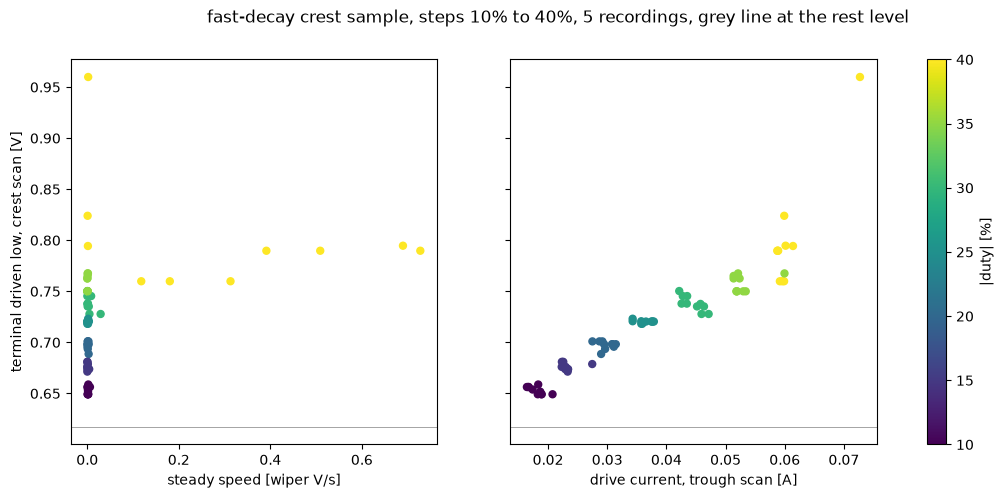

,steps,speed_mean_Vps,speed_max_Vps,reading_mean_V,reading_min_V,reading_max_V,high_terminal_mean_V,difference_mean_V,drive_current_A,corr_reading_speed_within_duty
duty_mag,,,,,,,,,,
10,10,0.002,0.006,0.653,0.649,0.659,0.595,-0.058,0.018,NaN
15,10,0.001,0.004,0.676,0.671,0.681,0.571,-0.104,0.023,NaN
20,10,0.002,0.003,0.697,0.689,0.701,0.521,-0.177,0.030,NaN
25,10,0.001,0.003,0.720,0.718,0.723,0.430,-0.290,0.036,NaN
30,10,0.005,0.029,0.738,0.728,0.750,0.297,-0.441,0.044,NaN
35,10,0.001,0.001,0.758,0.750,0.768,0.045,-0.712,0.053,NaN
40,10,0.293,0.728,0.802,0.760,0.960,-0.251,-1.053,0.061,-0.344


In [17]:
def fast_steps(df):
    vb_a, vb_b, bias = df["vb"].iloc[0], df["vb_b"].iloc[0], df["bias"].iloc[0]
    out = []
    for seg_id, seg in df.groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        if seg_id == 0 or d == 0:
            continue
        high, low, vb_h, vb_l = ("vmotor_a", "vmotor_b", vb_a, vb_b) if d > 0 else ("vmotor_b", "vmotor_a", vb_b, vb_a)
        out.append({
            "duty_pct": d,
            "duty_mag": round(abs(d)),
            "speed_Vps": abs(step_speed(step_window(seg))),
            "reading_V": ch.term_V(seg[low].median(), vb_l),
            "high_terminal_V": ch.term_V(seg[high].median(), vb_h),
            "difference_V": np.sign(d) * ch.diff_V(seg["vmotor_a"], seg["vmotor_b"], vb_a, vb_b).median(),
            "drive_current_A": (seg["current_trough"].mean() - bias) * ch.a_per_count,
        })
    return pd.DataFrame(out)

steps_b = pd.concat([fast_steps(df).assign(recording=n) for n, (df, _) in fast.items()],
                    ignore_index=True)
sel = steps_b[(steps_b["duty_mag"] >= 10) & (steps_b["duty_mag"] <= 40)]
VB_REST_V = ch.term_V(np.mean([df["vb"].iloc[0] for df, _ in fast.values()]),
                      np.mean([df["vb"].iloc[0] for df, _ in fast.values()]))   # a floating terminal at rest

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, x, xlabel in [(axes[0], "speed_Vps", "steady speed [wiper V/s]"),
                      (axes[1], "drive_current_A", "drive current, trough scan [A]")]:
    sc = ax.scatter(sel[x], sel["reading_V"], c=sel["duty_mag"], cmap="viridis", s=25)
    ax.axhline(VB_REST_V, color="grey", lw=0.5)
    ax.set_xlabel(xlabel)
axes[0].set_ylabel("terminal driven low, crest scan [V]")
fig.colorbar(sc, ax=axes, label="|duty| [%]")
fig.suptitle("fast-decay crest sample, steps 10% to 40%, 5 recordings, grey line at the rest level")
plt.show()

by_duty = sel.groupby("duty_mag").agg(
    steps=("speed_Vps", "size"),
    speed_mean_Vps=("speed_Vps", "mean"),
    speed_max_Vps=("speed_Vps", "max"),
    reading_mean_V=("reading_V", "mean"),
    reading_min_V=("reading_V", "min"),
    reading_max_V=("reading_V", "max"),
    high_terminal_mean_V=("high_terminal_V", "mean"),
    difference_mean_V=("difference_V", "mean"),
    drive_current_A=("drive_current_A", "mean"),
)
by_duty["corr_reading_speed_within_duty"] = sel.groupby("duty_mag").apply(
    lambda g: np.corrcoef(g["speed_Vps"], g["reading_V"])[0, 1] if g["speed_Vps"].std() > 0.01 else np.nan,
    include_groups=False)
by_duty.round(3)

Findings:

- From 10% to 35% the servo does not move under fast decay on this supply
  (speed under 0.03 wiper V/s in every recording) while the reading climbs
  from 0.65 V to 0.76 V with duty, 0.03 to 0.14 V above the 0.62 V level
  of a floating terminal at rest. A back-EMF is zero at zero speed.
- At 40%, where some recordings moved and some stalled, the reading
  spreads from 0.76 to 0.96 V and falls as speed rises within the duty
  (correlation -0.34 across the ten steps).
- The terminal driven high falls with duty, from 0.60 V at 10% to -0.25 V
  at 40%, so the rest-relative difference is opposite to the drive
  direction and grows with the drive current, from -0.06 V to -1.05 V.
- Against the drive current the reading is a single rising curve across
  all duties. Against speed it is a ladder of duty levels.

The reading tracks the winding current and has the wrong sign for a
back-EMF in the drive direction. It is not a back-EMF, and no $K_e$ is
taken from it. In this scan geometry the direct back-EMF is available only
from the coast segments, where the winding floats for the whole segment
and no PWM edge precedes the sample.

## 7. Route C: coast-down

### 7.1 Method

Within each coast segment the winding floats for 400 ms while the
mechanism spins down. Both terminals are readable, so the back-EMF is the
rest-relative terminal difference of section 2

$$e = V_a - V_b$$

which is positive during a forward coast and negative during a reverse
one, the same sign convention as the wiper speed. The samples of a coast
segment fall into three phases, and the histogram below separates them by
the corrected terminal sum $V_a + V_b$ (each terminal in absolute volts
with its own rest reading). It pools every coast sample of all 30
segments, split by position in the segment.

- The first two samples of a segment still read the drive, one terminal at
  the rail and the other near ground, so the sum sits at the rail, 4.5 V.
- The body-diode phase, while the winding current returns to the supply,
  puts one terminal a diode drop above the rail and the other a diode drop
  below ground. With drive currents under 0.1 A it lasts at most one
  sample, and the sum sits near the rail too.
- From then on the winding floats and the sum is the back-EMF plus twice
  the level of the negative terminal, under 1.3 V.

The gate is the corrected sum against half the rail. A sample is in the
drive or diode phase when $V_a + V_b$ exceeds half the rail, and only
samples from the third onward below that level are used. In a few segments
one further sample follows the diode phase with the polarity reversed, the
positive terminal at the diode level below ground and the other above it.
That sample fails the sign gate below.

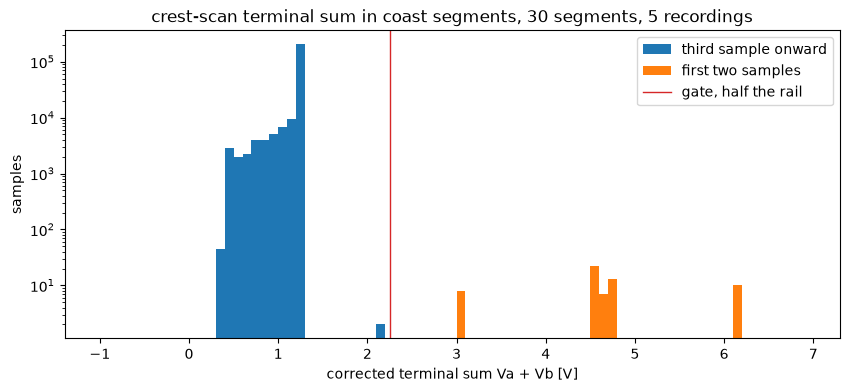

,samples,min_V,max_V,above_gate,rail_V
first two samples,60,3.007,6.166,60,4.51
third sample onward,239940,0.381,6.153,6,4.51


In [18]:
RAIL_V = pd.concat([s["rail_V"] for s in steps_a.values()]).mean()
SUM_GATE_V = RAIL_V / 2                  # corrected terminal sum above this is drive or diode phase

def terminals(seg, vb_a, vb_b):
    return ch.term_V(seg["vmotor_a"].to_numpy(), vb_a), ch.term_V(seg["vmotor_b"].to_numpy(), vb_b)

first_two, later = [], []
for df, meta in spin.values():
    vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
    for _, _, seg in coast_segments(df, meta):
        va, vb_ = terminals(seg, vb_a, vb_b)
        total = va + vb_
        first_two.append(total[:2])
        later.append(total[2:])
first_two, later = np.concatenate(first_two), np.concatenate(later)

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(-1, 7, 0.1)
ax.hist(later, bins=bins, log=True, color="tab:blue", label="third sample onward")
ax.hist(first_two, bins=bins, log=True, color="tab:orange", label="first two samples")
ax.axvline(SUM_GATE_V, color="tab:red", lw=1, label="gate, half the rail")
ax.set_xlabel("corrected terminal sum Va + Vb [V]")
ax.set_ylabel("samples")
ax.set_title("crest-scan terminal sum in coast segments, 30 segments, 5 recordings")
ax.legend()
plt.show()

pd.DataFrame({
    "samples": [len(first_two), len(later)],
    "min_V": [first_two.min(), later.min()],
    "max_V": [first_two.max(), later.max()],
    "above_gate": [(first_two > SUM_GATE_V).sum(), (later > SUM_GATE_V).sum()],
    "rail_V": [RAIL_V, RAIL_V],
}, index=["first two samples", "third sample onward"]).round(3)

The two populations do not touch. The first two samples of every segment
read the drive or the diode phase, 3.0 to 6.2 V, and six later samples,
the third sample of six segments, sit above the gate in the diode phase.
The gate at 2.3 V sits in the empty band between 1.3 V and 3.0 V.

Per sample from the third onward:

- **Back-EMF** $e$ as defined above, in volts at the terminals.
- **Speed** $\omega$ from a centred least-squares line over 41 samples
  (2 ms) of the wiper trace, evaluated at every sample.
- The used span runs from the first sample past the gate with $e$ of at
  least 0.02 V in the coast direction, which is the sign gate, to the
  first sample at which $|e|$ drops below 0.02 V, so the decay is covered
  and the span stops when the mechanism has come to rest. The regression
  additionally needs the centred window to fit inside the segment, which
  drops the first millisecond.

The wiper carries the noise. One ADC count over a 2 ms window is a speed
error of 0.4 V/s while the terminal difference is clean to 2.5 mV, so the
fit minimizes speed residuals, $\omega = e / K_e + \omega_0$, and reports
$K_e$ as the inverse slope. A regression of $e$ on the noisy speed would
read low by the noise-to-signal ratio of the speed. As an independent
check that needs no derivative, the integral of $e$ over the used span
divided by the wiper travel over the same span gives $K_e$ again, since
$\int e\,dt = K_e \int \omega\,dt = K_e\,\Delta p$.

On this supply the 20% coasts start from a back-EMF of 0.3 to 0.4 V and
are over in 10 to 50 ms, so their 2 ms derivative has almost nothing to
regress on. A coast shorter than 50 ms is flagged `short` below, kept in
the per-segment table, and left out of the per-segment summaries. The
pooled per-recording figures include every segment, weighted by its
travel, where the short ones count for little.

In [19]:
DERIV_WINDOW = 41          # samples, 2 ms centred fit
E_MIN_V = 0.02             # terminal volts, about 8 counts of tap difference
FIRST_SAMPLE = 2           # third sample of the segment onward
MIN_DECAY_MS = 50          # shorter decays are flagged short (see above)

def coast_trace(seg, vb_a, vb_b):
    d = int(seg["dir"].iloc[0])
    pos = seg["pos"].to_numpy() * ch.v_adc_per_count
    w = savgol_filter(pos, DERIV_WINDOW, 1, deriv=1, delta=1.0 / TICK_HZ)
    va, vb_ = terminals(seg, vb_a, vb_b)
    e = ch.diff_V(seg["vmotor_a"].to_numpy(), seg["vmotor_b"].to_numpy(), vb_a, vb_b)
    idx = np.arange(len(seg))
    ok = (idx >= FIRST_SAMPLE) & (va + vb_ < SUM_GATE_V) & (d * e >= E_MIN_V)
    start = np.flatnonzero(ok)[0]
    stop = np.flatnonzero(~ok & (idx > start))[0]      # mechanism at rest
    used = (idx >= start) & (idx < stop)
    # the centred derivative exists only where the window fits inside the segment
    fit = used & (idx >= DERIV_WINDOW // 2) & (idx < len(seg) - DERIV_WINDOW // 2)
    return idx / TICK_HZ, pos, w, e, used, fit, va, vb_

def coast_fits(df, meta):
    vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
    out = []
    for seg_id, level, seg in coast_segments(df, meta):
        d = int(seg["dir"].iloc[0])
        t, pos, w, e, used, fit, va, vb_ = coast_trace(seg, vb_a, vb_b)
        slope, icpt = np.polyfit(e[fit], w[fit], 1)
        span = np.flatnonzero(used)
        integral = np.trapezoid(e[used], t[used])
        travel = pos[span[-1]] - pos[span[0]]
        positive, negative = (va, vb_) if d > 0 else (vb_, va)
        decay_ms = (span[-1] - span[0]) / TICK_HZ * 1e3
        out.append({
            "seg": seg_id,
            "direction": d,
            "drive_pct": level,
            "samples_used": int(used.sum()),
            "samples_fit": int(fit.sum()),
            "decay_ms": decay_ms,
            "short": decay_ms < MIN_DECAY_MS,
            "e_start_V": e[span[0]],
            "negative_terminal_V": np.median(negative[span[0]:span[0] + 400]),
            "Ke_fit": 1.0 / slope,
            "w_intercept_Vps": icpt,
            "Ke_integral": integral / travel,
            "integral_Vs": integral,
            "travel_V": travel,
        })
    return pd.DataFrame(out)

coasts = pd.concat([coast_fits(df, meta).assign(recording=n) for n, (df, meta) in spin.items()],
                   ignore_index=True)
coasts[coasts["recording"] == "bridge-usb/capture-1"].set_index("seg").drop(
    columns=["recording", "integral_Vs", "travel_V"]).round(4)

,direction,drive_pct,samples_used,samples_fit,decay_ms,short,e_start_V,negative_terminal_V,Ke_fit,w_intercept_Vps,Ke_integral
seg,,,,,,,,,,,
2,1,20.0,187,169,9.3,True,0.4069,0.3431,8.4228,1.5239,0.3353
6,1,30.0,1587,1569,79.3,False,0.7323,-0.0058,0.2724,-0.1063,0.2985
10,1,40.0,2143,2125,107.1,False,1.0381,-0.3350,0.2892,0.1146,0.2729
14,-1,20.0,897,879,44.8,True,-0.2688,0.3459,0.2881,-0.0999,0.2547
18,-1,30.0,1619,1601,80.9,False,-0.5918,0.0076,0.2112,0.2600,0.2395
22,-1,40.0,2189,2171,109.4,False,-0.9888,-0.3470,0.2747,0.0055,0.2697


### 7.2 One decay

The forward coast after the 40% step of the first recording. The left
panel shows both terminals in corrected volts and their difference, the
middle panel the back-EMF and the wiper speed on one time axis, and the
right panel the fit.

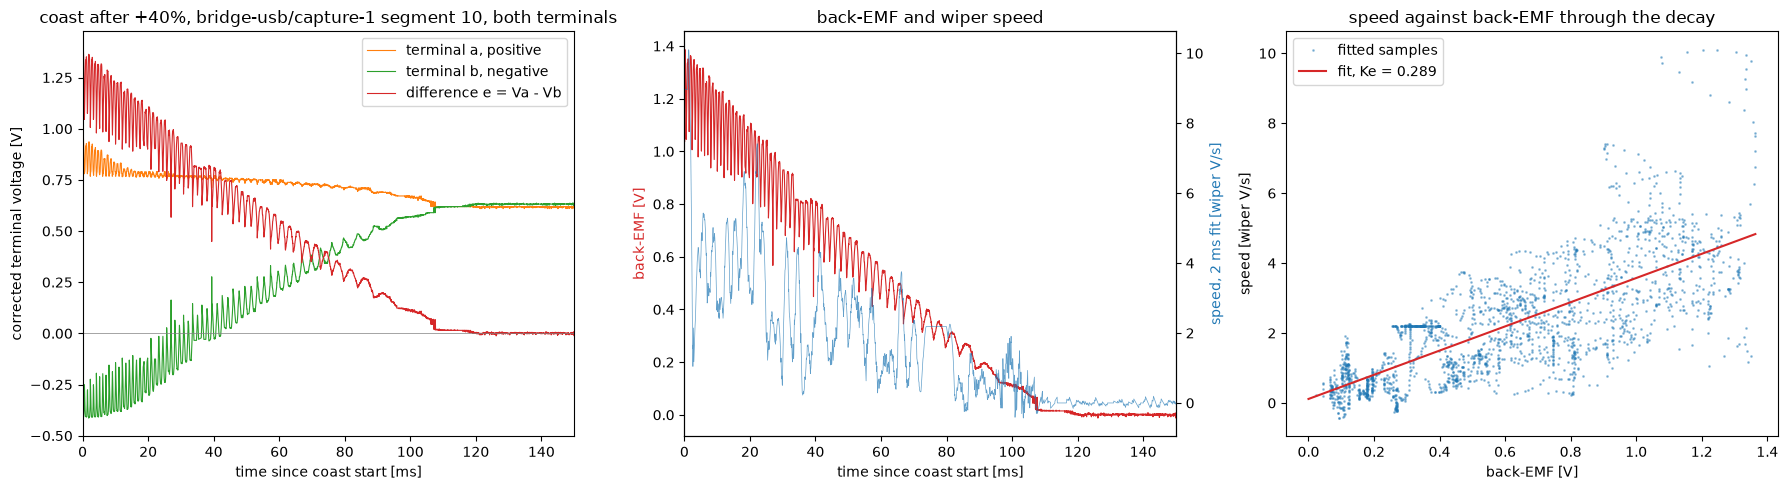

,samples_used,samples_fit,decay_ms,e_start_V,negative_terminal_V,Ke_fit,w_intercept_Vps,Ke_integral
2,2143,2125,107.1,1.0381,-0.335,0.2892,0.1146,0.2729


In [20]:
df_s, meta_s = spin["bridge-usb/capture-1"]
seg_id = int(coasts[(coasts["recording"] == "bridge-usb/capture-1")
                    & (coasts["direction"] == 1) & (coasts["drive_pct"] == 40)]["seg"].iloc[0])
seg = df_s[df_s["seg"] == seg_id]
t, pos, w, e, used, fit, va, vb_ = coast_trace(seg, df_s["vb"].iloc[0], df_s["vb_b"].iloc[0])
row = coasts[(coasts["recording"] == "bridge-usb/capture-1") & (coasts["seg"] == seg_id)].iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = axes[0]
ax.plot(t[FIRST_SAMPLE:] * 1e3, va[FIRST_SAMPLE:], color="tab:orange", lw=0.8, label="terminal a, positive")
ax.plot(t[FIRST_SAMPLE:] * 1e3, vb_[FIRST_SAMPLE:], color="tab:green", lw=0.8, label="terminal b, negative")
ax.plot(t[FIRST_SAMPLE:] * 1e3, e[FIRST_SAMPLE:], color="tab:red", lw=0.8, label="difference e = Va - Vb")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlim(0, 150)
ax.set_xlabel("time since coast start [ms]")
ax.set_ylabel("corrected terminal voltage [V]")
ax.set_title(f"coast after +40%, bridge-usb/capture-1 segment {seg_id}, both terminals")
ax.legend()
ax = axes[1]
ax.plot(t[FIRST_SAMPLE:] * 1e3, e[FIRST_SAMPLE:], color="tab:red", lw=0.8)
ax.set_xlabel("time since coast start [ms]")
ax.set_ylabel("back-EMF [V]", color="tab:red")
ax2 = ax.twinx()
ax2.plot(t * 1e3, w, color="tab:blue", lw=0.5, alpha=0.7)
ax2.set_ylabel("speed, 2 ms fit [wiper V/s]", color="tab:blue")
ax.set_xlim(0, 150)
ax.set_title("back-EMF and wiper speed")
ax = axes[2]
ax.plot(e[fit], w[fit], ".", ms=2, alpha=0.4, label="fitted samples")
ee = np.linspace(0, e[fit].max(), 10)
ax.plot(ee, ee / row["Ke_fit"] + row["w_intercept_Vps"], color="tab:red",
        label=f"fit, Ke = {row['Ke_fit']:.3f}")
ax.set_xlabel("back-EMF [V]")
ax.set_ylabel("speed [wiper V/s]")
ax.set_title("speed against back-EMF through the decay")
ax.legend()
fig.tight_layout()
plt.show()

pd.DataFrame([row[["samples_used", "samples_fit", "decay_ms", "e_start_V", "negative_terminal_V",
                   "Ke_fit", "w_intercept_Vps", "Ke_integral"]]]).round(4)

The back-EMF starts at 1.0 V, against 1.9 V after the same step on the
battery, and decays to zero within about 110 ms. The negative terminal
sits at -0.34 V while the back-EMF is near 1 V, the level at which the
body diode of the low-side switch conducts, and lifts toward the 0.63 V
rest level as the back-EMF falls, while the positive terminal
carries the rest of the swing. The single-terminal reading is therefore a
fraction of $e$ that changes through the decay, and the difference removes
it. Both traces carry a ripple of about 1 kHz at the start of the coast,
about 0.5 V peak to peak on the back-EMF, half the frequency of the ripple
seen at the battery's higher entry speed. *Hypothesis (not tested here):
this is the commutation ripple of the motor.* The scatter is a line with
the noise spread along the speed axis. The short horizontal run of fitted
points near 2 V/s is the pot's interpolated plateau through the band
below 1536 (section 4.3), a constant slope by construction.

### 7.3 All coast segments

Thirty coast segments, six per recording. The first table groups them by
direction and by the drive level that preceded the coast, which sets the
starting speed, with the short coasts left out of the summaries. The
second pools each recording's six segments, with the regression over all
their used samples and the ratio of the summed integrals to the summed
travel, both taken in the coast direction.

In [21]:
long = coasts[~coasts["short"]]
grouped = coasts.groupby(["direction", "drive_pct"]).agg(
    segments=("seg", "size"),
    short=("short", "sum"),
    decay_ms=("decay_ms", "mean"),
    e_start_V=("e_start_V", lambda x: x.abs().mean()),
    negative_terminal_V=("negative_terminal_V", "mean"),
    Ke_fit_mean=("Ke_fit", "mean"),
    Ke_fit_std=("Ke_fit", "std"),
    Ke_integral_mean=("Ke_integral", "mean"),
    Ke_integral_std=("Ke_integral", "std"),
)
overall = pd.DataFrame({
    "segments": [len(long)],
    "short": [0],
    "decay_ms": [long["decay_ms"].mean()],
    "e_start_V": [long["e_start_V"].abs().mean()],
    "negative_terminal_V": [long["negative_terminal_V"].mean()],
    "Ke_fit_mean": [long["Ke_fit"].mean()],
    "Ke_fit_std": [long["Ke_fit"].std()],
    "Ke_integral_mean": [long["Ke_integral"].mean()],
    "Ke_integral_std": [long["Ke_integral"].std()],
}, index=pd.MultiIndex.from_tuples([("all", "not short")], names=["direction", "drive_pct"]))
pd.concat([grouped, overall]).round(4)

segments  short  decay_ms  e_start_V  \
direction drive_pct                                         
-1        20.0              5      4   46.0300     0.3738   
          30.0              5      0   79.0800     0.7393   
          40.0              5      0  110.2100     1.0056   
1         20.0              5      5   37.1200     0.4034   
          30.0              5      0   77.9200     0.7131   
          40.0              5      0  107.2900     1.0366   
all       not short        21      0   91.5738     0.8491   

                     negative_terminal_V  Ke_fit_mean  Ke_fit_std  \
direction drive_pct                                                 
-1        20.0                    0.3437       0.3031      0.0505   
          30.0                    0.0067       0.2175      0.0121   
          40.0                   -0.3408       0.2778      0.0024   
1         20.0                    0.3476       1.9233      3.6336   
          30.0                    0.0078       0.2931      0.0218   
          40.0                   -0.3372       0.2992      0.0126   
all       not short              -0.1422       0.2695      0.0364   

                     Ke_integral_mean  Ke_integral_std  
direction drive_pct                                     
-1        20.0                 0.2806           0.0204  
          30.0                 0.2441           0.0097  
          40.0                 0.2732           0.0052  
1         20.0                 0.3277           0.0139  
          30.0                 0.3053           0.0103  
          40.0                 0.2783           0.0049  
all       not short            0.2756           0.0229

In [22]:
rows = []
for name, (df, meta) in spin.items():
    vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
    es, ws = [], []
    for _, _, seg in coast_segments(df, meta):
        _, _, w, e, used, fit, _, _ = coast_trace(seg, vb_a, vb_b)
        es.append(e[fit])
        ws.append(w[fit])
    es, ws = np.concatenate(es), np.concatenate(ws)
    slope, icpt = np.polyfit(es, ws, 1)
    c = coasts[coasts["recording"] == name]
    rows.append({"recording": name, "samples": len(es),
                 "Ke_regression": 1.0 / slope, "w_intercept_Vps": icpt,
                 "Ke_integral": (c["direction"] * c["integral_Vs"]).sum() / (c["direction"] * c["travel_V"]).sum()})
pooled_c = pd.DataFrame(rows).set_index("recording")
summary_c = pooled_c[["Ke_regression", "Ke_integral"]].agg(["mean", "std", "min", "max"]).T
summary_c["spread_pct"] = summary_c["std"] / summary_c["mean"] * 100
pd.concat([pooled_c.round(4), summary_c.round(4)], axis=0).fillna("")

,samples,Ke_regression,w_intercept_Vps,Ke_integral,mean,std,min,max,spread_pct
bridge-usb/capture-1,8514.0,0.272,-0.0563,0.27,,,,,
bridge-usb/capture-2,8973.0,0.2783,-0.0843,0.2738,,,,,
bridge-usb/capture-3,9315.0,0.278,-0.0592,0.2817,,,,,
bridge-usb/capture-4,9115.0,0.2804,-0.096,0.2785,,,,,
bridge-usb/capture-5,9346.0,0.2762,-0.1078,0.2796,,,,,
Ke_regression,,,,,0.277,0.0032,0.272,0.2804,1.1396
Ke_integral,,,,,0.2767,0.0047,0.27,0.2817,1.7133


The two directions do not agree as well as they did on the battery, and
the terminal split of section 2 is the first suspect, so the next table
pools the integral ratio by direction under the three readings of the
split. The adopted one is the rest-relative difference. The second is the
difference of the two per-terminal absolute voltages, which reads the
baseline split as -15 mV at rest. The third ignores the split and takes
the raw tap difference, as if both taps shared one bias, which reads -44
mV at rest. Alongside, the share of used samples in the 30% and 40%
decays at which the negative terminal was in the ADC's skipped band and
interpolated (section 4.3).

In [23]:
SPLIT_READINGS = {
    "rest-relative (adopted)": 0.0,
    "per-terminal absolute difference": 1.0,
    "raw tap difference, one shared bias": ch.div_ratio,
}
rows = []
for label, k in SPLIT_READINGS.items():
    by_dir = {1: [0.0, 0.0], -1: [0.0, 0.0]}
    for name, (df, meta) in spin.items():
        vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
        offset = k * (vb_a - vb_b) * ch.v_adc_per_count      # what this reading adds to e at rest
        for _, _, seg in coast_segments(df, meta):
            d = int(seg["dir"].iloc[0])
            t, pos, _, e, used, _, _, _ = coast_trace(seg, vb_a, vb_b)
            span = np.flatnonzero(used)
            by_dir[d][0] += d * np.trapezoid(e[used] + offset, t[used])
            by_dir[d][1] += d * (pos[span[-1]] - pos[span[0]])
    kf, kr = by_dir[1][0] / by_dir[1][1], by_dir[-1][0] / by_dir[-1][1]
    rows.append({"reading of the split": label, "e_at_rest_mV": k * (766 - 784) * ch.v_adc_per_count * 1e3,
                 "Ke_integral_forward": kf, "Ke_integral_reverse": kr,
                 "forward_minus_reverse_pct": (kf - kr) / ((kf + kr) / 2) * 100})
split_table = pd.DataFrame(rows).set_index("reading of the split")
display(split_table.round(4))

# share of used samples in which the negative terminal read a boundary code
# before interpolation (the loaded frames are already interpolated, so this
# re-reads the raw files for the count)
rows = []
for name, (df, meta) in spin.items():
    raw = pd.read_csv(TELEMETRY / "bridge-usb" / name.split("/")[1] / "spindown.csv.gz")
    vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
    for seg_id, level, seg in coast_segments(df, meta):
        if level < 30:
            continue
        d = int(seg["dir"].iloc[0])
        _, _, _, _, used, _, _, _ = coast_trace(seg, vb_a, vb_b)
        neg = "vmotor_b" if d > 0 else "vmotor_a"
        pinned = raw.loc[seg.index, neg].isin(PINNED_CODES).to_numpy()
        rows.append({"direction": d, "drive_pct": level, "used": int(used.sum()), "pinned": int((pinned & used).sum())})
p = pd.DataFrame(rows).groupby(["direction", "drive_pct"])[["used", "pinned"]].sum()
p["pinned_pct_of_used"] = p["pinned"] / p["used"] * 100
p.round(1)

,e_at_rest_mV,Ke_integral_forward,Ke_integral_reverse,forward_minus_reverse_pct
reading of the split,,,,
rest-relative (adopted),-0.0000,0.2901,0.2641,9.3890
per-terminal absolute difference,-14.5020,0.2816,0.2725,3.2783
"raw tap difference, one shared bias",-44.3848,0.2641,0.2900,-9.3158


used  pinned  pinned_pct_of_used
direction drive_pct                                   
-1        30.0        7913     490                 6.2
          40.0       11026     629                 5.7
 1        30.0        7797     401                 5.1
          40.0       10734     624                 5.8

Findings:

- Pooled per recording, the integral ratio gives 0.277 and the regression
  0.277, each repeating to under 2% across the five recordings.
- Per segment, leaving out the nine short 20% coasts, the integral gives
  0.276 with an 8% spread and the regression 0.270 with a 14% spread. The
  spread is between the groups, not within them. After a 40% step the two
  directions agree to 2% (0.278 forward, 0.273 reverse). After a 30% step
  they do not, 0.305 forward against 0.244 reverse, 22% apart, with each
  group repeating to 3 to 4%.
- The direction gap is 9% on the pooled integral with the adopted
  reading of the split, 3% with the per-terminal absolute difference
  and -9% with the raw tap difference, so a constant offset of about
  15 mV in $e$ would close it. But the same constant cannot explain a 22%
  gap at 30% next to a 2% gap at 40%, since a constant offset would hurt
  the slower group most and hurt both groups in the same direction. The
  adopted reading is the one that is zero at rest by measurement (section
  4.2), and the gap is left as it stands, with the two other readings
  showing its sensitivity.
- The skipped band of the ADC is where the negative terminal reads in
  these decays. It touched 5 to 6% of the used samples in the 30% and 40%
  decays, in both directions alike, and those samples were interpolated
  across. Even an error of the full 67 mV band width on every one of them
  would move $e$ by 4 mV on average, under 2% of $K_e$ in the 30% decays,
  so the band does not explain the 22% either.
- The negative terminal sits at -0.34 V through the 40% coasts, at the
  diode level, and near 0 V through the 30% coasts, whose back-EMF starts
  below the diode level. On the battery every 30% coast started above it.
- The 20% coasts start at 0.3 to 0.4 V and last 10 to 50 ms. Their
  integrals scatter from 0.25 to 0.35 and their regressions are not
  usable. They are in the table and in the pooled figures, where their
  small travel gives them little weight.

## 8. Agreement

The table collects every estimate with its spread. Route A is listed as
the free joint fit, whose spread is the collinearity of section 5.3, and
as the anchored result of section 5.5, whose spread combines the recording
spread with the shift induced by the anchor's bracket. Route C is listed
per segment (the 20 coasts that are not short) and pooled per recording
(5 recordings). The last column is each estimate's difference from the
anchored route A.

In [24]:
a_joint = fits_a["Ke_V_per_Vps"]
rows = [
    {"route": "A joint fit, free R", "Ke": a_joint.mean(), "spread": a_joint.std(), "n": len(a_joint), "n_unit": "recordings"},
    {"route": "A with R anchored", "Ke": KE_A, "spread": KE_A_SPREAD, "n": len(ke_anchor), "n_unit": "recordings"},
    {"route": "C regression, per segment", "Ke": long["Ke_fit"].mean(), "spread": long["Ke_fit"].std(), "n": len(long), "n_unit": "coast segments"},
    {"route": "C integral, per segment", "Ke": long["Ke_integral"].mean(), "spread": long["Ke_integral"].std(), "n": len(long), "n_unit": "coast segments"},
    {"route": "C regression, pooled per recording", "Ke": pooled_c["Ke_regression"].mean(), "spread": pooled_c["Ke_regression"].std(), "n": len(pooled_c), "n_unit": "recordings"},
    {"route": "C integral, pooled per recording", "Ke": pooled_c["Ke_integral"].mean(), "spread": pooled_c["Ke_integral"].std(), "n": len(pooled_c), "n_unit": "recordings"},
]
agree = pd.DataFrame(rows).set_index("route")
agree["spread_pct"] = agree["spread"] / agree["Ke"] * 100
agree["vs_A_anchored_pct"] = (agree["Ke"] / KE_A - 1) * 100
agree.round(4)

,Ke,spread,n,n_unit,spread_pct,vs_A_anchored_pct
route,,,,,,
"A joint fit, free R",0.1701,0.0071,15,recordings,4.1754,-48.6275
A with R anchored,0.3311,0.0067,15,recordings,2.0224,0.0000
"C regression, per segment",0.2695,0.0364,21,coast segments,13.5132,-18.6224
"C integral, per segment",0.2756,0.0229,21,coast segments,8.3065,-16.7853
"C regression, pooled per recording",0.2770,0.0032,5,recordings,1.1396,-16.3557
"C integral, pooled per recording",0.2767,0.0047,5,recordings,1.7133,-16.4356


In [25]:
def verdict(name):
    gap = agree.loc[name, "vs_A_anchored_pct"]
    combined = agree.loc["A with R anchored", "spread_pct"] + agree.loc[name, "spread_pct"]
    return {"route C estimate": name, "gap_pct": gap, "combined_spreads_pct": combined,
            "beyond_spreads_pct": max(abs(gap) - combined, 0), "within_spreads": abs(gap) <= combined}

KE_C = pooled_c["Ke_integral"].mean()
KE_ADOPTED = (KE_A + KE_C) / 2
KE_BRACKET_LO = min(ke_anchor["Ke_at_R_upper"].mean(),
                    pooled_c["Ke_integral"].mean() - pooled_c["Ke_integral"].std(),
                    pooled_c["Ke_regression"].mean() - pooled_c["Ke_regression"].std())
KE_BRACKET_HI = max(ke_anchor["Ke_at_R_lower"].mean(),
                    pooled_c["Ke_integral"].mean() + pooled_c["Ke_integral"].std(),
                    pooled_c["Ke_regression"].mean() + pooled_c["Ke_regression"].std())
pd.DataFrame([verdict("C integral, pooled per recording"),
              verdict("C regression, pooled per recording"),
              verdict("C integral, per segment")]).set_index("route C estimate").round(3)

,gap_pct,combined_spreads_pct,beyond_spreads_pct,within_spreads
route C estimate,,,,
"C integral, pooled per recording",-16.436,3.736,12.700,False
"C regression, pooled per recording",-16.356,3.162,13.194,False
"C integral, per segment",-16.785,10.329,6.456,False


In [26]:
pd.DataFrame([{
    "Ke_adopted": KE_ADOPTED,
    "bracket_low": KE_BRACKET_LO,
    "bracket_high": KE_BRACKET_HI,
    "half_width": (KE_BRACKET_HI - KE_BRACKET_LO) / 2,
    "half_width_pct": (KE_BRACKET_HI - KE_BRACKET_LO) / 2 / KE_ADOPTED * 100,
}]).round(4)

,Ke_adopted,bracket_low,bracket_high,half_width,half_width_pct
0,0.3039,0.272,0.335,0.0315,10.37


**Verdict.** The two routes sit 16% apart, route C below route A, against
the 5 to 7% of the earlier run on the battery, where route C was above.
The acceptance rule for a measured $K_e$ is two independent routes
agreeing within their stated spreads. Against the pooled route C figures,
whose spreads are under 2%, the gap exceeds the combined spreads by 13
points and the rule is not met. Against the per-segment integral, whose
8% spread is the group-to-group scatter of section 7.3, it is still not
met, by 6 points.

Whether the new chain changed the agreement is the question this run was
for, and the answer has two parts.

- **Route C moved down by 6%,** from 0.294 to 0.277 on the pooled
  integral, with a wider direction gap. The chain, the supply and the ADC
  band all changed at once. The band touched 4 to 5% of the samples it
  reads and cannot account for more than 2% (section 7.3), and the split
  reading can move it by 5% either way. The lower entry speeds on this
  supply put the negative terminal in the region where those two effects
  live, so I cannot separate chain from supply here.
- **Route A did not move when computed the earlier way** (0.283 here
  against 0.279 on the battery, section 5.5), and moved up by 17% when
  computed with all three means over one window, which is the definition
  this run adopts. That change is method, not chain or supply. On this
  supply the inrush is a large part of an 80 ms step, and the earlier
  definition's whole-step current is not the current of the tail whose
  speed it was paired with. The same fix applied to the retired battery
  recordings also raises route A there, so the earlier 5 to 7% agreement
  was partly the inrush hiding in the current.

What remains is a 16% gap with a constant-voltage shape. Section 5.5 shows
that a free constant of a quarter volt in the route A equation brings its
$K_e$ to 0.30, within 8% of route C, and section 9 lists what could
produce such a term. Until it is measured, the two routes bracket $K_e$
rather than pin it.

The bracket that covers both routes runs from 0.272, the pooled integral
less its spread, to 0.335, route A at the lower $R$ bound. Later
notebooks take the midpoint of the two routes, $K_e$ = 0.304 V per wiper
V/s, with the half-width of that bracket, 0.032 or 10%, as its
uncertainty. That is twice the uncertainty of the earlier run, and it is
the honest one.

## 9. Limitations and open issues

- **Nominal VDD.** $R$ and every voltage scale with the true VDD of this
  unit, which was not measured. $K_e$ is a ratio of two VDD-referenced
  voltages and is unaffected.
- **One servo, one supply.** All numbers describe this one unit on a
  laptop USB port, in one session, at a rail of 4.4 to 4.6 V that sags
  with load and dips by more than a volt at the start of a full-duty step.
- **The rig.** Section 1 describes it. The bus telemetry coupling into the
  current amplifier is worth a few mA at the lowest steps and nothing at
  the anchor's 0.8 A. The ADC of this build skips codes below its binary
  boundaries (section 4.3). Both are limitations of this board and
  build, and the only treatment here is the labeled interpolation of
  section 4.3, which the next board's notebooks should not need.
- **Route A collinearity.** Current and speed are 98 to 99% correlated
  across the grid, so the joint fit cannot split $R$ from $K_e$ and the
  anchor of section 5.4 carries the split.
- **Route A's missing term.** With $R$ anchored, the steps leave a
  constant deficit of 0.21 to 0.24 V that the two-term fit pushes into
  $K_e$ (section 5.5). Candidates are a brush contact drop, a loss at the
  bridge's switching edges (dead time, during which the current
  freewheels through the body diodes against the rail), and a current
  offset under drive of about 0.05 A that the rest baseline does not see.
  Each is a constant per period or per step and none is separable from
  this grid. A stall measurement at several currents, or drive steps at
  one speed and several duties, would separate them.
- **Route A's window.** The steps are not at steady state at 80 ms on
  this supply. The linear model does not need them to be, but the window
  choice moves $K_e$ by 2.4% between whole-step and last-60% means, and
  the earlier run's mixed-window definition moves it by 15%.
- **The pot reads off during the inrush.** In the first milliseconds of a
  full-duty step the pot reading shifts by 5 to 9 counts with the 0.8 A
  inrush and comes back as the current falls (section 5.4). It spoils the
  pot slope at the step edge and nothing else here, since every speed
  below is taken well after the inrush. Whether it is ground shift under
  the shunt current or the ADC under the sagging rail is open.
- **Residual motion on the R anchor.** Every full-duty step enters with a
  backward EMF of about 0.34 V from the seek, so the anchor window reads
  it on top of $R\,i$. The bounds of section 5.4 bracket $R$ to 5%. A
  seek that ends in a rest before the step would remove it.
- **Route C direction gap.** The 30% coasts give 0.305 forward and 0.244
  reverse and the 40% coasts agree to 2%. The two directions coast over
  different regions of the pot's travel, which is the one thing the
  groups differ in that a constant offset does not touch. Pot linearity
  is measured in notebook 06 and is not folded in here.
- **The terminal split.** The two taps rest 18 counts apart and the cause
  is open. The rest-relative difference is the reading that is zero at
  rest, and the other two readings move the pooled route C by up to 5%
  and its direction gap by 20 points (section 7.3).
- **Pot speed axis.** The wiper's volts per radian along its travel, and
  the 1 kHz ripple on the decay, act on the two routes differently.
  Neither is measured here.
- **Rejected candidate.** The fast-decay crest sample reads a
  current-dependent transient with the wrong sign at 10% to 40% duty. In
  this scan geometry it is not a back-EMF channel.
- **Gear ratio unknown.** $K_e$ is referenced to the pot wiper. The motor
  shaft constant is this value times the wiper volts per motor radian,
  which requires the gear ratio and the pot's volts per radian.

## 10. What later notebooks use

- $K_e$ = 0.304 V per wiper V/s, the midpoint of the two routes, with a
  bracket of 0.272 to 0.335 that covers both routes and their spreads.
  Route A alone gives 0.331, route C alone 0.277, and the routes do not
  meet the acceptance rule on this data.
- $R$ = 4.54 Ohm from the full-duty anchor, with the 4.31 to 4.76 Ohm
  bracket of the residual-motion caveat, and the route A combination
  $R + 57\,K_e \approx 23.5$ Ohm, which is what the drive grid pins on
  its own at this supply.
- The terminal conversion $V_t = r\,\text{tap} - (r - 1)\,V_B$ with each
  terminal's own rest reading as $V_B$, and the terminal difference taken
  relative to the rest reading of each tap, which is zero for a floating
  winding at rest (sections 2 and 4.2).
- Route A's per-step quantities are means over one window of the step,
  voltage, current and speed alike, with the applied voltage from the
  per-sample terminal difference and never from a nominal rail.
- The ADC of this build skips codes below 128, 256, 512, 1024, 1536 (pot)
  and 2560 (terminals) and reports the boundary code. Any notebook on
  this build that reads a channel through one of those bands needs the
  interpolation of section 4.3 or a statement of why it does not.
- The coast-segment convention of section 7 (back-EMF as the
  rest-relative terminal difference, third sample onward, sum gate at
  half the rail, sign gate at 0.02 V, 2 ms centred derivative, speed
  regressed on back-EMF, integral cross-check, coasts under 50 ms flagged
  short).
- The negative terminal of a floating winding sits at the diode level of
  about -0.34 V whenever the back-EMF exceeds about 1 V, so a
  single-terminal reading is a variable fraction of the back-EMF and
  nothing downstream should use one.
- The fast-decay crest sample is a current channel in the OFF portion, and
  nothing downstream should read it as back-EMF.